# 05 · Support Vector Classifier

We build the SVM **step by step, with a picture at every step**:

1. a hyperplane splits the space in two, and the sign of $f(\mathbf{x})$ tells us the side;
2. the dot product is a **projection**, so it measures distances along $\boldsymbol{\theta}$;
3. we use the free scale of $\boldsymbol{\theta}$ to put the closest points at $f = \pm 1$;
4. projecting those points gives the **margin width** $2/\lVert\boldsymbol{\theta}\rVert$;
5. maximising it is a convex **optimisation** problem.

Then we solve it (Lagrange multipliers → the dual → **kernels**) and finish by showing that the whole thing is
just **regularised hinge loss**, the same template as logistic regression.

**Contents**

*Part I · Building the SVM geometrically*
1. Setup and notation
2. Step 1 · The hyperplane and the decision rule
3. Step 2 · The dot product is a projection
4. Step 3 · From "$>0$" to "$\ge 1$": fixing the scale
5. Step 4 · Measuring the margin by projecting
6. Step 5 · The optimisation problem

*Part II · Solving it*

7. Lagrange multipliers and the dual
8. Soft margin: slack variables and $C$
9. The kernel trick

*Part III · The same model as a loss*

10. The hinge loss
11. Training with sub-gradient descent, and support vectors
12. Practical notes and summary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from sklearn.svm import SVC
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(3)
POS, NEG, NORMAL = "C3", "C0", "purple"          # class +1, class -1, the normal vector θ

def scatter_classes(ax, X, y, s=30):
    ax.scatter(X[y > 0, 0], X[y > 0, 1], c=POS, marker="o", edgecolor="k", s=s, zorder=3, label="$y=+1$")
    ax.scatter(X[y < 0, 0], X[y < 0, 1], c=NEG, marker="s", edgecolor="k", s=s, zorder=3, label="$y=-1$")

def draw_boundary(ax, theta, theta0, lim, margins=True, shade=True):
    # f(x) = 0 (solid) and f(x) = ±1 (dashed) for f(x) = θ·x + θ0, on the square lim × lim
    g1, g2 = np.meshgrid(np.linspace(*lim, 400), np.linspace(*lim, 400))
    F = theta[0] * g1 + theta[1] * g2 + theta0
    if shade:
        ax.contourf(g1, g2, F, levels=[-1e9, 0, 1e9], colors=[NEG, POS], alpha=0.08)
    if margins:
        ax.contour(g1, g2, F, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
    else:
        ax.contour(g1, g2, F, levels=[0], colors="k", linewidths=2)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")

def plot_svm(ax, theta, theta0, X, y, title, lim=(-3.5, 4.5)):
    draw_boundary(ax, theta, theta0, lim)
    scatter_classes(ax, X, y)
    sv = y * (X @ theta + theta0) <= 1 + 1e-3
    ax.scatter(X[sv, 0], X[sv, 1], s=180, facecolors="none", edgecolors="k", lw=1.5, zorder=4)
    ax.set_title(title + f"\nmargin width 2/‖θ‖ = {2 / np.linalg.norm(theta):.2f}, ringed: μ ≤ 1")

## 1. Setup and notation

- Labels are $y^{(i)}\in\{-1, +1\}$ (not 0/1): it makes the formulas symmetric.
- Linear score: $f(\mathbf{x}) = \boldsymbol{\theta}^\top\mathbf{x} + \theta_0$, prediction $\hat{y} = \mathrm{sign}(f(\mathbf{x}))$.
- Here $\boldsymbol{\theta}\in\mathbb{R}^n$ holds only the **weights**, and the intercept $\theta_0$ is kept **separate**, because it must not appear in the margin $2/\lVert\boldsymbol{\theta}\rVert$. (Slides and books often write $\mathbf{w}\cdot\mathbf{x} + b$ for $\boldsymbol{\theta}^\top\mathbf{x} + \theta_0$.)
- **Functional margin** of example $i$: $\;\mu^{(i)} = y^{(i)}f(\mathbf{x}^{(i)}) = y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0)$.
  $\mu^{(i)} > 0$ ⇔ correctly classified. The larger it is, the more "confidently" correct.

The question of this notebook, in one picture: many lines separate the data. **Which one should we pick?**

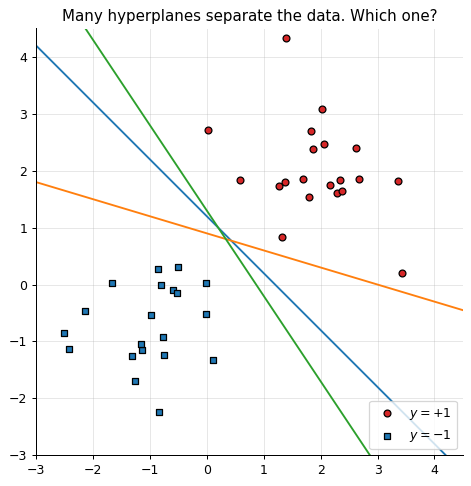

In [2]:
# Two separable clouds (used throughout Part I)
m_half = 20
Xa = rng.normal([2, 2], 0.7, (m_half, 2)); Xb = rng.normal([-1, -0.5], 0.7, (m_half, 2))
X = np.r_[Xa, Xb]; y = np.r_[np.ones(m_half), -np.ones(m_half)]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
scatter_classes(ax, X, y)
xs = np.linspace(-3, 4.5, 10)
for a, b, c in [(1, 1, -1.2), (0.3, 1, -0.9), (1.5, 1, -1.3)]:       # a x1 + b x2 + c = 0
    ax.plot(xs, -(a * xs + c) / b, lw=1.5)
ax.set_xlim(-3, 4.5); ax.set_ylim(-3, 4.5); ax.set_aspect("equal"); ax.legend(loc="lower right")
ax.set_title("Many hyperplanes separate the data. Which one?")
plt.tight_layout(); plt.show()

## 2. Step 1 · The hyperplane and the decision rule

A hyperplane is the set of points where the linear score is zero:

$$
\mathcal{H} = \{\mathbf{x}:\ \boldsymbol{\theta}^\top\mathbf{x} + \theta_0 = 0\},
\qquad\text{in 2-D: }\ \theta_1x_1 + \theta_2x_2 + \theta_0 = 0 .
$$

In 2-D this is **one equation in two unknowns**, so one coordinate is free: the solutions form a line. In $\mathbb{R}^n$ it is an $(n-1)$-dimensional "flat" (a plane in 3-D, and so on).

The hyperplane cuts the space in two halves, and the **sign** of $f$ tells us which half a point is in:

$$
\hat{y} = \begin{cases} +1 & \text{if } \boldsymbol{\theta}^\top\mathbf{x} + \theta_0 > 0\\ -1 & \text{if } \boldsymbol{\theta}^\top\mathbf{x} + \theta_0 < 0 \end{cases}
$$

**Worked example.** $\boldsymbol{\theta} = (1, 1)$, $\theta_0 = -3$, i.e. the line $x_1 + x_2 - 3 = 0$:

| point | $f(\mathbf{x}) = x_1 + x_2 - 3$ | prediction |
|---|---|---|
| $\mathbf{x}^{(1)} = (3, 3)$ | $+3$ | $+1$ |
| $\mathbf{x}^{(2)} = (0, 0)$ | $-3$ | $-1$ |
| $(1.5, 1.5)$ | $0$ | on the boundary |

In the figure the grey lines are the **level sets** $f = \text{const}$. They are all parallel to the boundary, and $f$ grows in the direction of $\boldsymbol{\theta}$ (the purple arrow). So the sign of $f$ gives the side. Does the size $|f|$ give the distance? Not yet: step 2 shows we have to divide by $\lVert\boldsymbol{\theta}\rVert$.

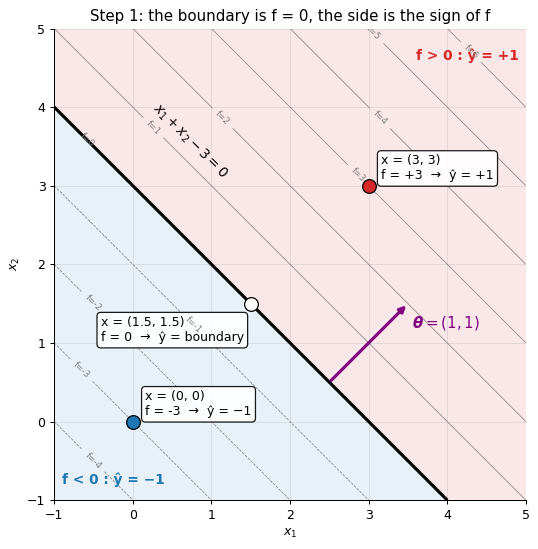

In [3]:
theta_ex, theta0_ex = np.array([1.0, 1.0]), -3.0
lim = (-1, 5)
g1, g2 = np.meshgrid(np.linspace(*lim, 400), np.linspace(*lim, 400))
F = theta_ex[0] * g1 + theta_ex[1] * g2 + theta0_ex

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.contourf(g1, g2, F, levels=[-1e9, 0, 1e9], colors=[NEG, POS], alpha=0.10)
cs = ax.contour(g1, g2, F, levels=np.arange(-4, 7), colors="gray", linewidths=0.6)
ax.clabel(cs, fmt="f=%d", fontsize=7)
ax.contour(g1, g2, F, levels=[0], colors="k", linewidths=2.5)
ax.annotate("", xy=(3.5, 1.5), xytext=(2.5, 0.5), arrowprops=dict(arrowstyle="-|>", color=NORMAL, lw=2.5))
ax.text(3.55, 1.2, r"$\boldsymbol{\theta}=(1,1)$", color=NORMAL, fontsize=12)
ax.text(0.2, 3.1, r"$x_1 + x_2 - 3 = 0$", rotation=-45, fontsize=11)
for p, c, off in [((3, 3), POS, (10, 5)), ((0, 0), NEG, (10, 5)), ((1.5, 1.5), "w", (-120, -30))]:
    f = theta_ex @ p + theta0_ex
    pred = "+1" if f > 0 else ("−1" if f < 0 else "boundary")
    ax.scatter(*p, s=120, c=c, edgecolor="k", zorder=5)
    ax.annotate(f"x = ({p[0]:g}, {p[1]:g})\nf = {f:+g}  →  ŷ = {pred}".replace("+0 ", "0 "), p, xytext=off, textcoords="offset points",
                fontsize=10, bbox=dict(boxstyle="round", fc="w", alpha=0.9))
ax.text(3.6, 4.6, "f > 0 : ŷ = +1", color=POS, fontsize=11, weight="bold")
ax.text(-0.9, -0.8, "f < 0 : ŷ = −1", color=NEG, fontsize=11, weight="bold")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Step 1: the boundary is f = 0, the side is the sign of f")
plt.tight_layout(); plt.show()

## 3. Step 2 · The dot product is a projection

The dot product has two equivalent forms:

$$
\boldsymbol{\theta}^\top\mathbf{x} = \sum_{j=1}^n\theta_jx_j = \lVert\boldsymbol{\theta}\rVert\,\lVert\mathbf{x}\rVert\cos\alpha,
\qquad \lVert\boldsymbol{\theta}\rVert = \sqrt{\textstyle\sum_j\theta_j^2}.
$$

$\lVert\mathbf{x}\rVert\cos\alpha$ is the length of the **shadow** of $\mathbf{x}$ on the direction of $\boldsymbol{\theta}$ (left figure). To read off that length directly we normalise $\boldsymbol{\theta}$ to the unit vector $\hat{\boldsymbol{\theta}} = \boldsymbol{\theta}/\lVert\boldsymbol{\theta}\rVert$:

$$
\text{shadow of } \mathbf{x} \text{ on } \boldsymbol{\theta} \;=\; \hat{\boldsymbol{\theta}}^\top\mathbf{x} \;=\; \frac{\boldsymbol{\theta}^\top\mathbf{x}}{\lVert\boldsymbol{\theta}\rVert}.
$$

Now rewrite the score with it: $f(\mathbf{x}) = \lVert\boldsymbol{\theta}\rVert\big(\hat{\boldsymbol{\theta}}^\top\mathbf{x} + \theta_0/\lVert\boldsymbol{\theta}\rVert\big)$. Two consequences (right figure):

**(a) What the hyperplane is.** $f(\mathbf{x}) = 0$ ⇔ $\hat{\boldsymbol{\theta}}^\top\mathbf{x} = -\theta_0/\lVert\boldsymbol{\theta}\rVert$. The hyperplane is the set of all points whose shadow on $\boldsymbol{\theta}$ has the **same length** $-\theta_0/\lVert\boldsymbol{\theta}\rVert$. So:
- $\boldsymbol{\theta}$ is **perpendicular** to the hyperplane (all its points drop onto the same spot of the $\boldsymbol{\theta}$ axis);
- the hyperplane sits at distance $|\theta_0|/\lVert\boldsymbol{\theta}\rVert$ from the origin. $\theta_0$ only **slides** it along $\boldsymbol{\theta}$ (this is the $-b/\lVert w\rVert$ on the slides).

**(b) Distance from a point to the hyperplane.** Distances along $\boldsymbol{\theta}$ are differences of shadows:

$$
r(\mathbf{x}) = \hat{\boldsymbol{\theta}}^\top\mathbf{x} - \Big(-\frac{\theta_0}{\lVert\boldsymbol{\theta}\rVert}\Big)
\quad\Longrightarrow\quad
\boxed{r(\mathbf{x}) = \frac{\boldsymbol{\theta}^\top\mathbf{x} + \theta_0}{\lVert\boldsymbol{\theta}\rVert} = \frac{f(\mathbf{x})}{\lVert\boldsymbol{\theta}\rVert}}
$$

$r$ is signed: positive on the side $\boldsymbol{\theta}$ points to. That answers step 1: $f$ is the distance **times** $\lVert\boldsymbol{\theta}\rVert$.

*Example.* $\boldsymbol{\theta} = (1,1)$, $\theta_0 = -3$, $\mathbf{x} = (4,2)$: $r = 3/\sqrt2 \approx 2.12$. Check: the closest point of the line is $(2.5, 0.5)$, and $\lVert(4,2)-(2.5,0.5)\rVert = \sqrt{1.5^2+1.5^2} = 2.12$ ✓.

For a training point, multiplying by the label gives the **geometric margin** (its unsigned distance, if it is correctly classified):
$$
\gamma^{(i)} = \frac{y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0)}{\lVert\boldsymbol{\theta}\rVert} = \frac{\mu^{(i)}}{\lVert\boldsymbol{\theta}\rVert}.
$$

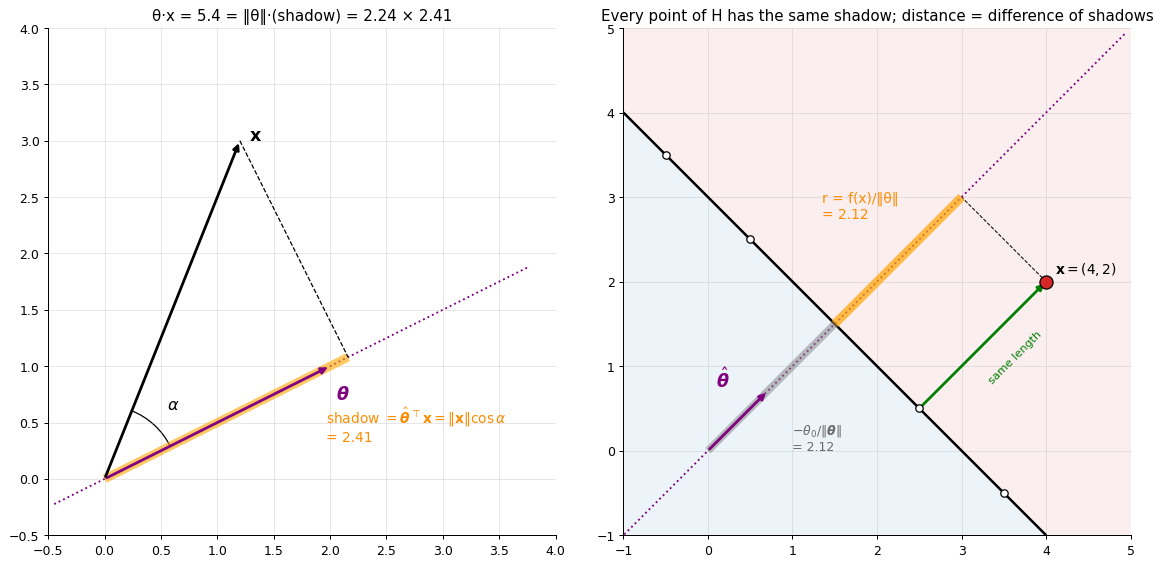

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2))
arrow = lambda ax, tip, tail=(0, 0), c="k": ax.annotate("", xy=tip, xytext=tail,
                                                        arrowprops=dict(arrowstyle="-|>", color=c, lw=2.2))

# --- left: dot product = length of the shadow
ax = axes[0]
th, xv = np.array([2.0, 1.0]), np.array([1.2, 3.0])
th_hat = th / np.linalg.norm(th); shadow = th_hat @ xv; foot = shadow * th_hat
t = np.linspace(-0.5, 4.2, 2); ax.plot(t * th_hat[0], t * th_hat[1], ":", c=NORMAL)          # the θ axis
ax.plot([0, foot[0]], [0, foot[1]], c="orange", lw=7, alpha=0.6, solid_capstyle="butt")
ax.plot([xv[0], foot[0]], [xv[1], foot[1]], "k--", lw=1)
arrow(ax, th, c=NORMAL); arrow(ax, xv)
a1, a2 = np.degrees(np.arctan2(th[1], th[0])), np.degrees(np.arctan2(xv[1], xv[0]))
ax.add_patch(Arc((0, 0), 1.3, 1.3, theta1=a1, theta2=a2)); ax.text(0.55, 0.62, r"$\alpha$", fontsize=13)
ax.text(*(th + [0.05, -0.3]), r"$\boldsymbol{\theta}$", color=NORMAL, fontsize=14)
ax.text(*(xv + [0.08, 0]), r"$\mathbf{x}$", fontsize=14)
ax.text(foot[0] - 0.2, foot[1] - 0.75, r"shadow $=\hat{\boldsymbol{\theta}}^\top\mathbf{x}=\|\mathbf{x}\|\cos\alpha$" + f"\n= {shadow:.2f}",
        color="darkorange", fontsize=11)
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4); ax.set_aspect("equal")
ax.set_title(f"θ·x = {th @ xv:.1f} = ‖θ‖·(shadow) = {np.linalg.norm(th):.2f} × {shadow:.2f}")

# --- right: the hyperplane is "all points with the same shadow"
ax = axes[1]
lim = (-1, 5)
draw_boundary(ax, theta_ex, theta0_ex, lim, margins=False)
u = theta_ex / np.linalg.norm(theta_ex); t = np.linspace(-1.4, 7, 2)
ax.plot(t * u[0], t * u[1], ":", c=NORMAL); arrow(ax, u, c=NORMAL)
ax.text(0.1, 0.75, r"$\hat{\boldsymbol{\theta}}$", color=NORMAL, fontsize=14)
foot0 = -theta0_ex / np.linalg.norm(theta_ex) * u                                       # (1.5, 1.5)
for p in [(0.5, 2.5), (2.5, 0.5), (3.5, -0.5), (-0.5, 3.5)]:                              # points on H
    ax.plot([p[0], foot0[0]], [p[1], foot0[1]], "k--", lw=0.8); ax.scatter(*p, s=35, c="w", edgecolor="k", zorder=4)
ax.plot([0, foot0[0]], [0, foot0[1]], c="gray", lw=6, alpha=0.5, solid_capstyle="butt")
ax.text(1.0, 0.0, r"$-\theta_0/\|\boldsymbol{\theta}\|$" + f"\n= {foot0 @ u:.2f}", fontsize=10, color="dimgray")
xq = np.array([4.0, 2.0]); rq = (theta_ex @ xq + theta0_ex) / np.linalg.norm(theta_ex); fq = (u @ xq) * u
ax.scatter(*xq, s=110, c=POS, edgecolor="k", zorder=5); ax.text(4.1, 2.1, r"$\mathbf{x}=(4,2)$", fontsize=11)
ax.plot([xq[0], fq[0]], [xq[1], fq[1]], "k--", lw=0.8)
ax.plot([foot0[0], fq[0]], [foot0[1], fq[1]], c="orange", lw=7, alpha=0.7, solid_capstyle="butt")
ax.text(1.35, 2.75, f"r = f(x)/‖θ‖\n= {rq:.2f}", color="darkorange", fontsize=11)
arrow(ax, xq, xq - rq * u, c="green"); ax.text(3.3, 0.8, "same length", color="green", fontsize=9, rotation=45)
ax.set_title("Every point of H has the same shadow; distance = difference of shadows")
plt.tight_layout(); plt.show()

## 4. Step 3 · From "$>0$" to "$\ge 1$": fixing the scale

**Scale invariance.** Multiply $(\boldsymbol{\theta}, \theta_0)$ by any $c > 0$:
$\;c\,\boldsymbol{\theta}^\top\mathbf{x} + c\,\theta_0 = 0 \iff \boldsymbol{\theta}^\top\mathbf{x} + \theta_0 = 0$.
Same hyperplane, same predictions, same distances $r = f/\lVert\boldsymbol{\theta}\rVert$ (numerator and denominator both scale by $c$). Only the numbers $f(\mathbf{x})$ change. So $\boldsymbol{\theta}$ has one "free knob", its length, that does not change the classifier (figure: the solid line never moves).

**We spend that freedom.** Take a separating hyperplane placed halfway between the two classes (sliding it with $\theta_0$ to the middle can only increase the smallest distance, so the best one is there anyway). Choose $c$ so that the **closest points** of each class have $f = +1$ and $f = -1$. Then every point satisfies

$$
\begin{cases}
\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0 \ge +1 & \text{for all } i \text{ with } y^{(i)} = +1\\
\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0 \le -1 & \text{for all } i \text{ with } y^{(i)} = -1
\end{cases}
\quad\Longleftrightarrow\quad
\boxed{y^{(i)}\big(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0\big) \ge 1\quad\forall i}
$$

(the $\pm1$ labels merge the two cases into one line), with **equality** exactly for the closest points:

$$
y^{(i)}\big(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0\big) - 1 = 0 \qquad\text{(support vectors)}.
$$

The two dashed lines $f(\mathbf{x}) = \pm 1$ are the **margin boundaries**. Between them there are no training points. In the figure, only $c = 1$ makes the dashed lines pass through the closest points.

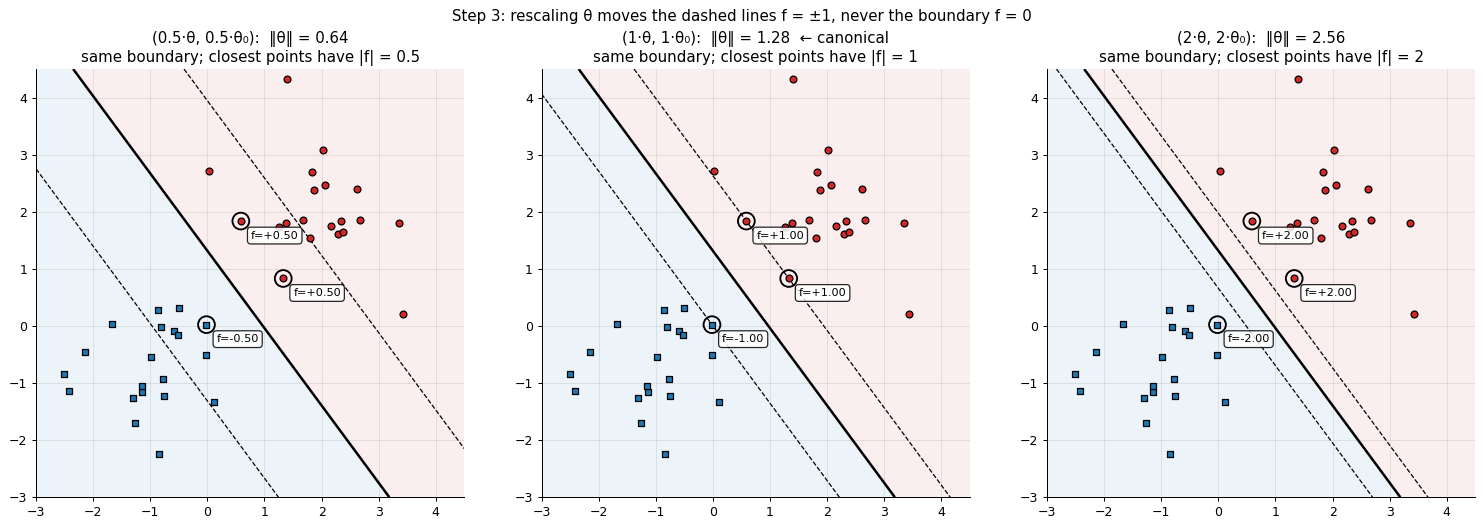

In [5]:
hard = SVC(kernel="linear", C=1e6).fit(X, y)                 # (practically) hard margin, canonical scale
th_c, th0_c = hard.coef_[0], hard.intercept_[0]
sv_idx = hard.support_

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
for ax, c in zip(axes, [0.5, 1.0, 2.0]):
    th, th0 = c * th_c, c * th0_c
    draw_boundary(ax, th, th0, (-3, 4.5)); scatter_classes(ax, X, y)
    ax.scatter(X[sv_idx, 0], X[sv_idx, 1], s=180, facecolors="none", edgecolors="k", lw=1.5, zorder=4)
    for i in sv_idx:
        ax.annotate(f"f={X[i] @ th + th0:+.2f}", X[i], xytext=(8, -14), textcoords="offset points", fontsize=9,
                    bbox=dict(boxstyle="round", fc="w", alpha=0.85))
    tag = "  ← canonical" if c == 1 else ""
    ax.set_title(f"({c:g}·θ, {c:g}·θ₀):  ‖θ‖ = {np.linalg.norm(th):.2f}{tag}\n"
                 f"same boundary; closest points have |f| = {c:g}")
fig.suptitle("Step 3: rescaling θ moves the dashed lines f = ±1, never the boundary f = 0", y=1.0)
plt.tight_layout(); plt.show()

## 5. Step 4 · Measuring the margin by projecting

How wide is the band between the dashed lines? **Project!** Take a support vector $\mathbf{x}_+$ on $f = +1$ and a support vector $\mathbf{x}_-$ on $f = -1$. By step 2, their distance measured along $\boldsymbol{\theta}$ is the difference of their shadows:

$$
d = \underbrace{\frac{\boldsymbol{\theta}^\top\mathbf{x}_+}{\lVert\boldsymbol{\theta}\rVert}}_{d_+} - \underbrace{\frac{\boldsymbol{\theta}^\top\mathbf{x}_-}{\lVert\boldsymbol{\theta}\rVert}}_{d_-}
= \frac{1}{\lVert\boldsymbol{\theta}\rVert}\big(\boldsymbol{\theta}^\top\mathbf{x}_+ - \boldsymbol{\theta}^\top\mathbf{x}_-\big).
$$

The support-vector equations of step 3 give $\boldsymbol{\theta}^\top\mathbf{x}_+ + \theta_0 = +1$ and $\boldsymbol{\theta}^\top\mathbf{x}_- + \theta_0 = -1$, i.e. $\boldsymbol{\theta}^\top\mathbf{x}_+ = 1 - \theta_0$ and $\boldsymbol{\theta}^\top\mathbf{x}_- = -1 - \theta_0$. Substituting:

$$
d = \frac{1}{\lVert\boldsymbol{\theta}\rVert}\big((1 - \theta_0) - (-1 - \theta_0)\big) = \frac{1 - \theta_0 + 1 + \theta_0}{\lVert\boldsymbol{\theta}\rVert}
\quad\Longrightarrow\quad
\boxed{\;d = \frac{2}{\lVert\boldsymbol{\theta}\rVert}\;}
$$

$\theta_0$ cancels, and so does the choice of which support vectors we took. The same result from the distance formula: each dashed line is at distance $1/\lVert\boldsymbol{\theta}\rVert$ from the boundary, one on each side.

> **Key idea.** Once the scale is fixed, **a short $\boldsymbol{\theta}$ means a wide margin.**

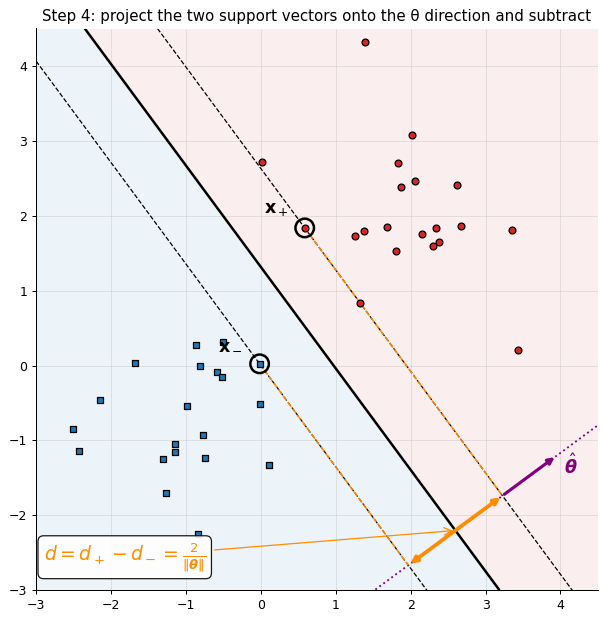

d+ - d- = (θ·x+ − θ·x−)/‖θ‖ = 1.5621
2/‖θ‖                      = 1.5619


In [6]:
th, th0 = th_c, th0_c
u = th / np.linalg.norm(th)
i_pos = next(i for i in sv_idx if y[i] > 0); i_neg = next(i for i in sv_idx if y[i] < 0)
xp, xm = X[i_pos], X[i_neg]
p0 = np.array([2.6, -2.2])                            # any axis parallel to θ works: shadow differences are the same
foot = lambda x: p0 + (u @ (x - p0)) * u
fp, fm = foot(xp), foot(xm)

fig, ax = plt.subplots(figsize=(7, 7))
draw_boundary(ax, th, th0, (-3, 4.5)); scatter_classes(ax, X, y)
t = np.linspace(-6, 6, 2); ax.plot(p0[0] + t * u[0], p0[1] + t * u[1], ":", c=NORMAL, lw=1.5)
ax.annotate("", xy=fp + 0.9 * u, xytext=fp, arrowprops=dict(arrowstyle="-|>", color=NORMAL, lw=2.5))
ax.text(*(fp + 0.9 * u + [0.1, -0.25]), r"$\hat{\boldsymbol{\theta}}$", color=NORMAL, fontsize=14)
for p, f_, lab in [(xp, fp, r"$\mathbf{x}_+$"), (xm, fm, r"$\mathbf{x}_-$")]:
    ax.scatter(*p, s=220, facecolors="none", edgecolors="k", lw=2, zorder=5)
    ax.plot([p[0], f_[0]], [p[1], f_[1]], c="darkorange", ls="--", lw=1.2)     # runs along the dashed margin line
    ax.text(*(p + [-0.55, 0.2]), lab, fontsize=14)
ax.annotate("", xy=fp, xytext=fm, arrowprops=dict(arrowstyle="<|-|>", color="darkorange", lw=3))
ax.annotate(r"$d = d_+ - d_- = \frac{2}{\|\boldsymbol{\theta}\|}$", (fp + fm) / 2, xytext=(-2.9, -2.6),
            color="darkorange", fontsize=15, bbox=dict(boxstyle="round", fc="w", alpha=0.9),
            arrowprops=dict(arrowstyle="->", color="darkorange"))
ax.set_title("Step 4: project the two support vectors onto the θ direction and subtract")
plt.tight_layout(); plt.show()

print(f"d+ - d- = (θ·x+ − θ·x−)/‖θ‖ = {(th @ xp - th @ xm) / np.linalg.norm(th):.4f}")
print(f"2/‖θ‖                      = {2 / np.linalg.norm(th):.4f}")

## 6. Step 5 · The optimisation problem

We want the widest margin that still has every point on its correct side, outside the band:

$$
\max_{\boldsymbol{\theta},\theta_0}\ \frac{2}{\lVert\boldsymbol{\theta}\rVert}
\qquad\text{s.t.}\quad y^{(i)}\big(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0\big) - 1 \ge 0,\quad \forall i .
$$

Maximising $2/a$ (with $a > 0$) is the same as minimising $a$, and the same as minimising $\frac12a^2$. Squaring removes the square root in $\lVert\boldsymbol{\theta}\rVert$ and makes the objective smooth; the $\frac12$ cancels the 2 when we differentiate. So the **hard-margin SVM** is

$$
\boxed{\min_{\boldsymbol{\theta},\theta_0}\ \frac12\lVert\boldsymbol{\theta}\rVert^2 = \frac12\boldsymbol{\theta}^\top\boldsymbol{\theta}
\qquad\text{s.t.}\quad y^{(i)}\big(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0\big) \ge 1,\quad i = 1,\dots,m}
$$

- It is a **convex quadratic program (QP)**: a convex quadratic objective with linear constraints. It has a single global optimum, and standard QP software solves it.
- **Only some constraints matter.** There is one constraint per point, but at the optimum only the ones that hold with *equality* (the support vectors, on the dashed lines) are "active". Delete every other point and the solution does not change. Section 7 makes this precise.
- **Why a large margin?** A boundary far from all training points is robust to small perturbations of the data. Statistical learning theory backs this up: the generalisation bound depends on (data radius / margin)², not on the dimension $n$.

**The picture behind the problem.** For each direction $\hat{\boldsymbol{\theta}}$ (an angle $\varphi$ in 2-D), project all points onto it. The widest band that fits in that direction is the gap between the lowest shadow of the $+1$ class and the highest shadow of the $-1$ class. The SVM picks the direction with the **largest gap**.

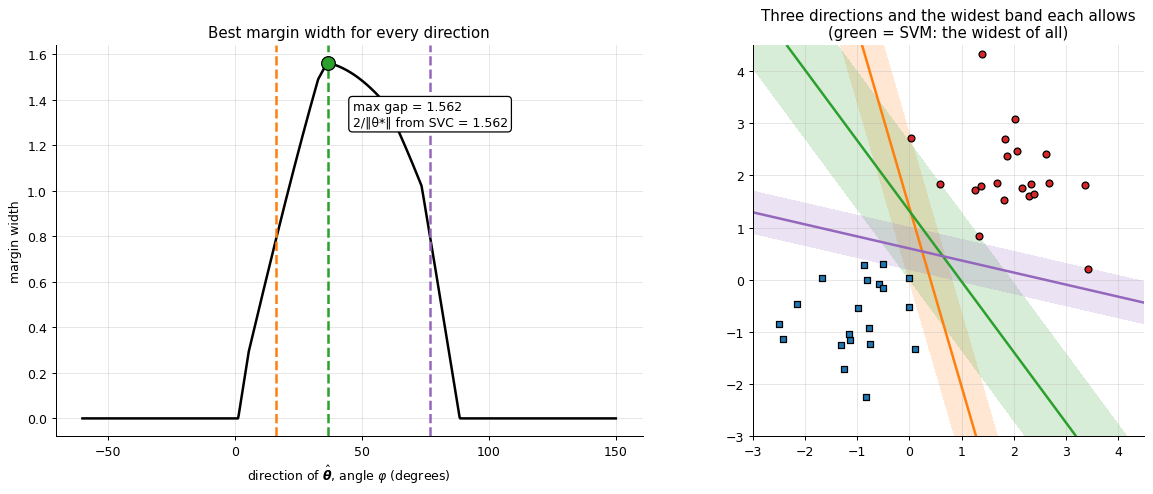

In [7]:
def gap_along(phi, X, y):
    # widest margin achievable with normal direction u = (cos φ, sin φ); negative = not separable that way
    u = np.array([np.cos(phi), np.sin(phi)])
    s = X @ u                                                   # shadows on u
    lo, hi = s[y > 0].min(), s[y < 0].max()
    return lo - hi, u, (lo + hi) / 2

phis = np.radians(np.linspace(-60, 150, 841))
gaps = np.array([gap_along(p, X, y)[0] for p in phis])
k = gaps.argmax(); phi_star = phis[k]
ok = np.where(gaps > 0.5 * gaps[k])[0]                                   # two sub-optimal directions
examples = [(phis[ok[0]], "C1"), (phi_star, "C2"), (phis[ok[-1]], "C4")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax = axes[0]
ax.plot(np.degrees(phis), np.clip(gaps, 0, None), "k", lw=2)
for p, c in examples:
    ax.axvline(np.degrees(p), color=c, lw=2, ls="--")
ax.scatter(np.degrees(phi_star), gaps[k], s=120, c="C2", zorder=4, edgecolor="k")
ax.annotate(f"max gap = {gaps[k]:.3f}\n2/‖θ*‖ from SVC = {2 / np.linalg.norm(th_c):.3f}", (np.degrees(phi_star), gaps[k]),
            xytext=(20, -50), textcoords="offset points", fontsize=10, bbox=dict(boxstyle="round", fc="w"))
ax.set_xlabel(r"direction of $\hat{\boldsymbol{\theta}}$, angle $\varphi$ (degrees)"); ax.set_ylabel("margin width")
ax.set_title("Best margin width for every direction")

ax = axes[1]
lim = (-3, 4.5); g1, g2 = np.meshgrid(np.linspace(*lim, 400), np.linspace(*lim, 400))
for p, c in examples:
    gap, u, mid = gap_along(p, X, y)
    th, th0 = 2 * u / gap, -2 * mid / gap                              # canonical scale: f = ±1 at the band edges
    F = th[0] * g1 + th[1] * g2 + th0
    ax.contourf(g1, g2, F, levels=[-1, 1], colors=[c], alpha=0.18)
    ax.contour(g1, g2, F, levels=[0], colors=[c], linewidths=2)
scatter_classes(ax, X, y); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_title("Three directions and the widest band each allows\n(green = SVM: the widest of all)")
plt.tight_layout(); plt.show()

## 7. Lagrange multipliers and the dual

**The idea of Lagrange multipliers, for inequality constraints.** Minimise $g(\boldsymbol{\theta})$ subject to $h_i(\boldsymbol{\theta}) \ge 0$. At the optimum, either a constraint is **inactive** ($h_i > 0$, you could move a little without violating it, so it plays no role), or it is **active** ($h_i = 0$, the optimum is pressed against it). At the optimum the gradient of the objective is a non-negative combination of the gradients of the active constraints:

$$
\nabla g = \sum_i\alpha_i\nabla h_i,\qquad \alpha_i \ge 0,\qquad \alpha_i\,h_i = 0 \ \ \text{(inactive ⇒ } \alpha_i = 0\text{)} .
$$

The figure below shows it for our SVM, in $\boldsymbol{\theta}$-space (with $\theta_0$ fixed at its optimal value). Each training point is a half-plane of allowed $\boldsymbol{\theta}$. Their intersection is the feasible region. The objective $\frac12\lVert\boldsymbol{\theta}\rVert^2$ has circular level sets, and the optimum is where the **smallest circle touches the feasible region**. It touches only a few constraint lines, the support vectors, and $\boldsymbol{\theta}^*$ is a weighted sum of their normals $y^{(i)}\mathbf{x}^{(i)}$.

**The Lagrangian.** With one multiplier $\alpha_i \ge 0$ per constraint:

$$
\mathcal{L}(\boldsymbol{\theta},\theta_0,\boldsymbol{\alpha}) = \frac12\lVert\boldsymbol{\theta}\rVert^2 - \sum_{i=1}^m\alpha_i\Big[y^{(i)}\big(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0\big) - 1\Big].
$$

**Stationarity** (derivatives w.r.t. the primal variables equal zero):

$$
\nabla_{\boldsymbol{\theta}}\mathcal{L} = \boldsymbol{\theta} - \sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)} = \mathbf{0}
\;\Rightarrow\; \boxed{\boldsymbol{\theta} = \sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)}},
\qquad
\frac{\partial\mathcal{L}}{\partial\theta_0} = -\sum_i\alpha_iy^{(i)} = 0 \;\Rightarrow\; \sum_i\alpha_iy^{(i)} = 0 .
$$

**Substitute back.** Expand $\mathcal{L} = \frac12\boldsymbol{\theta}^\top\boldsymbol{\theta} - \sum_i\alpha_iy^{(i)}\boldsymbol{\theta}^\top\mathbf{x}^{(i)} - \theta_0\sum_i\alpha_iy^{(i)} + \sum_i\alpha_i$. The $\theta_0$ term is zero. With $\boldsymbol{\theta} = \sum_j\alpha_jy^{(j)}\mathbf{x}^{(j)}$, both $\boldsymbol{\theta}^\top\boldsymbol{\theta}$ and $\sum_i\alpha_iy^{(i)}\boldsymbol{\theta}^\top\mathbf{x}^{(i)}$ are equal to $\sum_{i,j}\alpha_i\alpha_jy^{(i)}y^{(j)}\mathbf{x}^{(i)\top}\mathbf{x}^{(j)}$, so $\frac12$ of it minus all of it leaves $-\frac12$ of it. This gives the **dual problem**:

$$
\boxed{\max_{\boldsymbol{\alpha}}\ \sum_i\alpha_i - \frac12\sum_{i,j}\alpha_i\alpha_j\,y^{(i)}y^{(j)}\,\mathbf{x}^{(i)\top}\mathbf{x}^{(j)}
\qquad\text{s.t.}\quad \alpha_i \ge 0,\quad \sum_i\alpha_iy^{(i)} = 0}
$$

**Complementary slackness (KKT):** $\alpha_i\big[y^{(i)}f(\mathbf{x}^{(i)}) - 1\big] = 0$. So $\alpha_i > 0$ **only for points exactly on the margin**. These are the support vectors, and $\boldsymbol{\theta}$ is built from them alone. The intercept follows from any support vector $s$: $y^{(s)}(\boldsymbol{\theta}^\top\mathbf{x}^{(s)} + \theta_0) = 1 \Rightarrow \theta_0 = y^{(s)} - \boldsymbol{\theta}^\top\mathbf{x}^{(s)}$.

**Prediction** needs only the support vectors and dot products:
$$
f(\mathbf{x}) = \sum_{i\in\text{SV}}\alpha_iy^{(i)}\,\mathbf{x}^{(i)\top}\mathbf{x} + \theta_0 .
$$
Keep an eye on that dot product $\mathbf{x}^{(i)\top}\mathbf{x}$: it is the door to kernels (section 9).

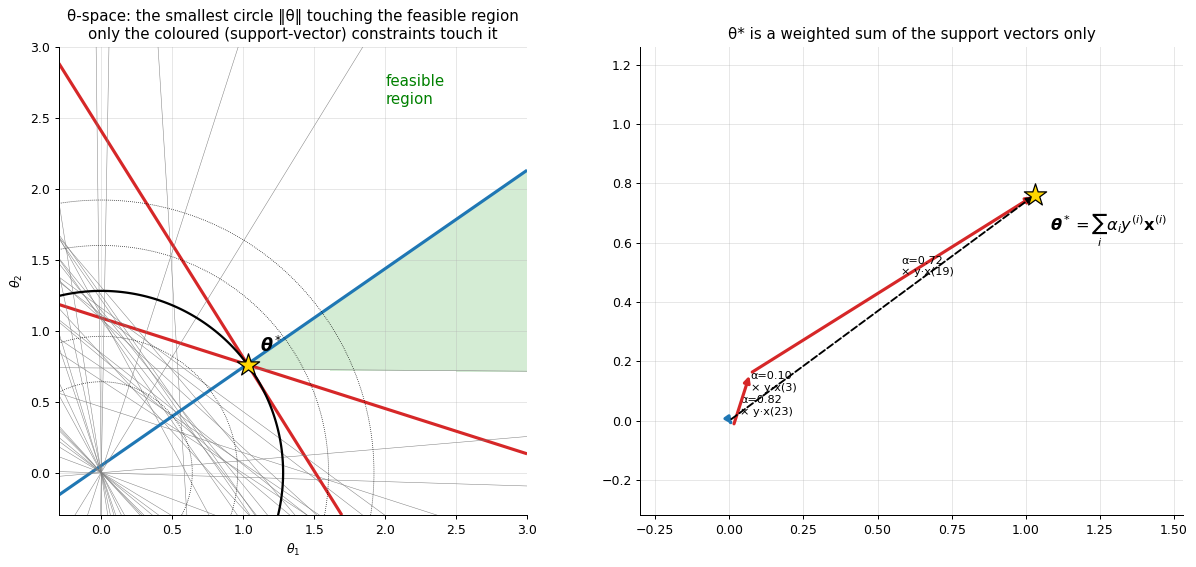

support vectors: [23  3 19]  α = [0.8198 0.097  0.7229]  Σ α_i y_i = -0.0


In [8]:
# θ-space picture: feasible region, level circles of ½‖θ‖², and the active constraints
A = y[:, None] * X                          # constraint i:  (y_i x_i)·θ ≥ 1 − y_i θ0*
b = 1 - y * th0_c
T1, T2 = np.meshgrid(np.linspace(-0.3, 3.0, 500), np.linspace(-0.3, 3.0, 500))
Tgrid = np.c_[T1.ravel(), T2.ravel()]
feasible = (Tgrid @ A.T >= b).all(1).reshape(T1.shape)
alpha_y = hard.dual_coef_[0]                  # α_i y_i for the support vectors

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))
ax = axes[0]
ax.contourf(T1, T2, feasible, levels=[0.5, 1.5], colors=["C2"], alpha=0.2)
for i in range(len(y)):
    active = i in sv_idx
    ax.contour(T1, T2, (A[i, 0] * T1 + A[i, 1] * T2 - b[i]), levels=[0],
               colors=[POS if y[i] > 0 else NEG] if active else ["gray"], linewidths=2.5 if active else 0.4)
R = np.hypot(T1, T2); r_star = np.linalg.norm(th_c)
ax.contour(T1, T2, R, levels=r_star * np.array([0.5, 0.75, 1.25, 1.5]), colors="k", linewidths=0.6, linestyles=":")
ax.contour(T1, T2, R, levels=[r_star], colors="k", linewidths=1.8)
ax.scatter(*th_c, marker="*", s=350, c="gold", edgecolor="k", zorder=5)
ax.annotate(r"$\boldsymbol{\theta}^*$", th_c, xytext=(10, 10), textcoords="offset points", fontsize=14)
ax.text(2.0, 2.6, "feasible\nregion", color="green", fontsize=12)
ax.set_xlim(-0.3, 3); ax.set_ylim(-0.3, 3); ax.set_aspect("equal")
ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$")
ax.set_title("θ-space: the smallest circle ‖θ‖ touching the feasible region\n"
             "only the coloured (support-vector) constraints touch it")

ax = axes[1]                                   # θ* = Σ α_i y_i x_i, drawn tip to tail
tail, pts = np.zeros(2), [np.zeros(2)]
for coef, i in zip(alpha_y, sv_idx):
    tip = tail + coef * X[i]
    ax.annotate("", xy=tip, xytext=tail, arrowprops=dict(arrowstyle="-|>", color=POS if y[i] > 0 else NEG, lw=2.5))
    ax.text(*((tail + tip) / 2 + [0.03, 0.03]), f"α={abs(coef):.2f}\n× y·x({i})", fontsize=9)
    tail = tip; pts.append(tip)
ax.annotate("", xy=th_c, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color="k", lw=1.5, ls="--"))
ax.scatter(*th_c, marker="*", s=350, c="gold", edgecolor="k", zorder=5)
ax.text(*(th_c + [0.05, -0.12]), r"$\boldsymbol{\theta}^*=\sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)}$", fontsize=13)
pts = np.array(pts); lo, hi = pts.min(0) - 0.3, pts.max(0) + 0.5
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_aspect("equal")
ax.set_title("θ* is a weighted sum of the support vectors only")
plt.tight_layout(); plt.show()
print("support vectors:", sv_idx, " α =", np.abs(alpha_y).round(4), " Σ α_i y_i =", alpha_y.sum().round(6))

**Solving the dual ourselves.** The dual is a QP in $m$ variables with simple constraints. For small $m$ a generic solver is enough. We write it with a kernel argument $K(\mathbf{x}, \mathbf{z})$ (for now the plain dot product) so we can reuse it in section 9, and a box $0 \le \alpha_i \le C$ that we explain in section 8 ($C = \infty$ is the hard margin).

our dual : theta = [1.0303 0.7604], theta0 = -1.0011, support vectors = [ 3 19 23]
sklearn  : theta = [1.0301 0.7606], theta0 = -1.0012, support vectors = [ 3 19 23]


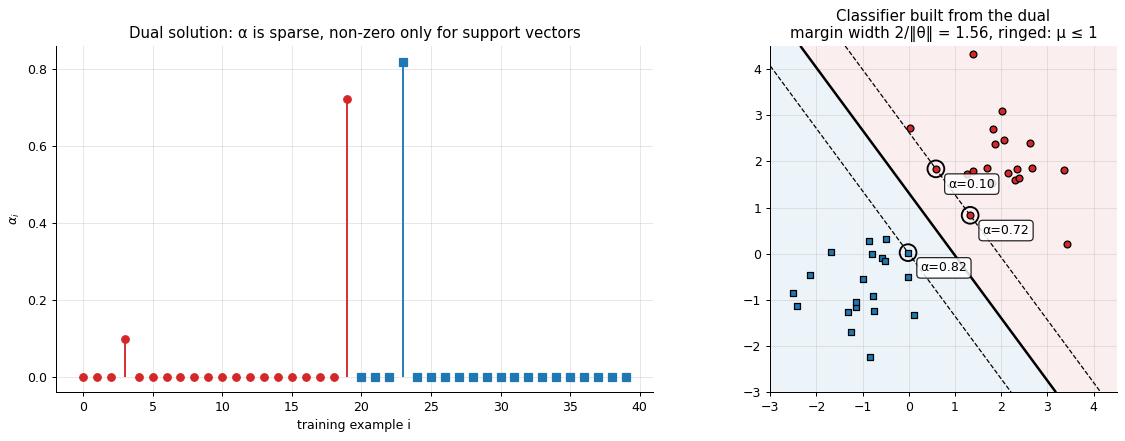

In [9]:
from scipy.optimize import minimize

linear_kernel = lambda A, B: A @ B.T

def svm_dual(X, y, C=np.inf, kernel=linear_kernel):
    m = len(y)
    Q = (y[:, None] * y[None, :]) * kernel(X, X)             # Q_ij = y_i y_j K(x_i, x_j)
    res = minimize(lambda a: 0.5 * a @ Q @ a - a.sum(),       # minimise −(dual objective)
                   np.zeros(m), jac=lambda a: Q @ a - 1, method="SLSQP",
                   bounds=[(0, None if np.isinf(C) else C)] * m,
                   constraints=[{"type": "eq", "fun": lambda a: a @ y, "jac": lambda a: y}],
                   options={"maxiter": 2000, "ftol": 1e-12})
    alpha = np.where(res.x > 1e-6, res.x, 0.0)
    on_margin = (alpha > 1e-6) & (alpha < (C - 1e-6 if np.isfinite(C) else np.inf))
    theta0 = np.mean(y[on_margin] - (alpha * y) @ kernel(X, X[on_margin]))    # θ0 = y_s − Σ α_i y_i K(x_i, x_s)
    return alpha, theta0

alpha, theta0_d = svm_dual(X, y)
theta_d = (alpha * y) @ X                                     # θ = Σ α_i y_i x_i
print(f"our dual : theta = {theta_d.round(4)}, theta0 = {theta0_d:.4f}, support vectors = {np.flatnonzero(alpha)}")
print(f"sklearn  : theta = {th_c.round(4)}, theta0 = {th0_c:.4f}, support vectors = {np.sort(sv_idx)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.stem(np.arange(len(y))[y > 0], alpha[y > 0], linefmt=POS, markerfmt="o", basefmt=" ")
ax.stem(np.arange(len(y))[y < 0], alpha[y < 0], linefmt=NEG, markerfmt="s", basefmt=" ")
ax.set_xlabel("training example i"); ax.set_ylabel(r"$\alpha_i$")
ax.set_title("Dual solution: α is sparse, non-zero only for support vectors")
plot_svm(axes[1], theta_d, theta0_d, X, y, "Classifier built from the dual", lim=(-3, 4.5))
for i in np.flatnonzero(alpha):
    axes[1].annotate(f"α={alpha[i]:.2f}", X[i], xytext=(10, -15), textcoords="offset points", fontsize=10,
                     bbox=dict(boxstyle="round", fc="w", alpha=0.85))
plt.tight_layout(); plt.show()

## 8. Soft margin: slack variables and $C$

Real data overlap, and then no $\boldsymbol{\theta}$ satisfies all the constraints $y^{(i)}f(\mathbf{x}^{(i)}) \ge 1$. Allow each point a **slack** $\xi^{(i)}\ge0$ and pay for it:

$$
\boxed{\min_{\boldsymbol{\theta},\theta_0,\boldsymbol{\xi}}\;\frac12\lVert\boldsymbol{\theta}\rVert^2 + C\sum_{i=1}^m\xi^{(i)} \quad\text{s.t.}\quad y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)} + \theta_0) \ge 1 - \xi^{(i)},\quad \xi^{(i)}\ge0}
$$

Geometrically (step 2), $\xi^{(i)}/\lVert\boldsymbol{\theta}\rVert$ is **how far point $i$ is on the wrong side of its own dashed line** (arrows in the figure):

| slack | meaning |
|---|---|
| $\xi^{(i)} = 0$ | on the correct side, outside or on the margin |
| $0 < \xi^{(i)} \le 1$ | correct side but inside the margin |
| $\xi^{(i)} > 1$ | misclassified |

$\sum_i\xi^{(i)}$ is an upper bound on the number of training mistakes. $C>0$ trades margin width against violations:
- **large $C$**: violations are expensive → narrow margin, fits the training data tightly (low bias, high variance). $C\to\infty$ recovers the hard margin.
- **small $C$**: wide margin, many violations tolerated (more regularisation).

**Dual.** Repeating section 7 with multipliers $\nu_i \ge 0$ for $\xi^{(i)} \ge 0$ adds the stationarity condition $\partial\mathcal{L}/\partial\xi^{(i)} = C - \alpha_i - \nu_i = 0$. Since $\nu_i \ge 0$ this gives $\alpha_i \le C$. The dual is **the same problem with the box $0 \le \alpha_i \le C$**. KKT now reads: $\alpha_i = 0$ outside the margin, $0 < \alpha_i < C$ exactly on the margin, $\alpha_i = C$ inside the margin or misclassified.

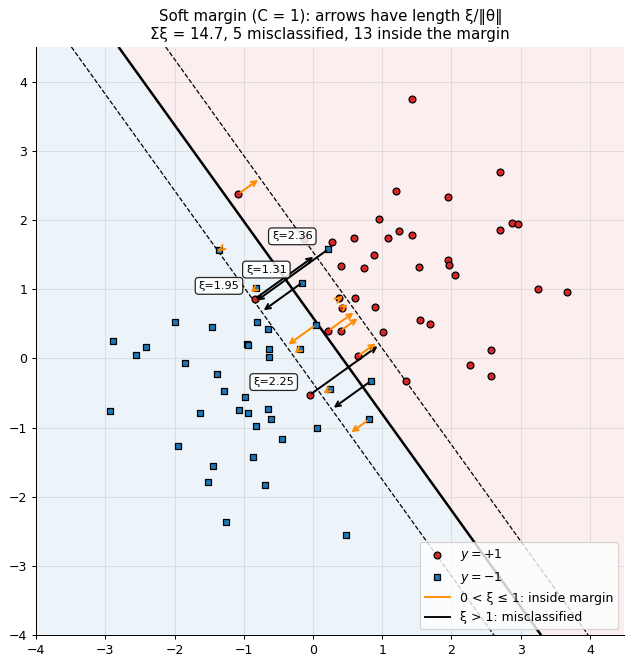

In [10]:
Xo = np.r_[rng.normal([1.2, 1.2], 1.0, (40, 2)), rng.normal([-0.8, -0.6], 1.0, (40, 2))]
yo = np.r_[np.ones(40), -np.ones(40)]
lim_o = (-4, 4.5)

soft = SVC(kernel="linear", C=1).fit(Xo, yo)
th, th0 = soft.coef_[0], soft.intercept_[0]
nrm = np.linalg.norm(th); u = th / nrm
mu_o = yo * (Xo @ th + th0); xi = np.maximum(0, 1 - mu_o)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
draw_boundary(ax, th, th0, lim_o); scatter_classes(ax, Xo, yo)
for i in np.flatnonzero(xi > 1e-6):
    target = Xo[i] + yo[i] * xi[i] / nrm * u               # the point moved onto its own dashed line
    col = "darkorange" if xi[i] <= 1 else "k"
    ax.annotate("", xy=target, xytext=Xo[i], arrowprops=dict(arrowstyle="->", color=col, lw=1.6))
for i in np.argsort(xi)[-4:]:
    ax.annotate(f"ξ={xi[i]:.2f}", Xo[i], xytext=(-45, 8), textcoords="offset points", fontsize=9,
                bbox=dict(boxstyle="round", fc="w", alpha=0.85))
ax.plot([], [], c="darkorange", label="0 < ξ ≤ 1: inside margin"); ax.plot([], [], c="k", label="ξ > 1: misclassified")
ax.legend(loc="lower right")
ax.set_title(f"Soft margin (C = 1): arrows have length ξ/‖θ‖\nΣξ = {xi.sum():.1f}, "
             f"{(xi > 1).sum()} misclassified, {((xi > 0) & (xi <= 1)).sum()} inside the margin")
plt.tight_layout(); plt.show()

### The effect of $C$ on overlapping data

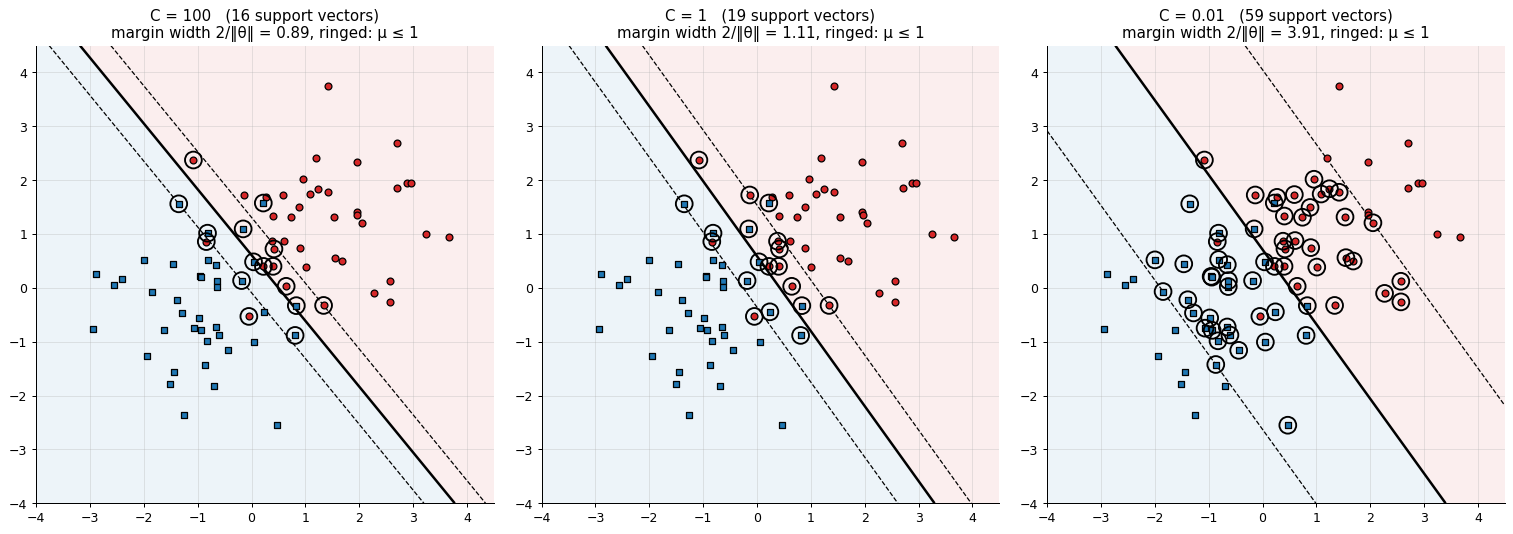

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))
for ax, C in zip(axes, [100, 1, 0.01]):
    s = SVC(kernel="linear", C=C).fit(Xo, yo)
    plot_svm(ax, s.coef_[0], s.intercept_[0], Xo, yo, f"C = {C}   ({len(s.support_)} support vectors)", lim=lim_o)
plt.tight_layout(); plt.show()

## 9. The kernel trick

**The problem.** Some data cannot be separated by any hyperplane. **The fix:** map every point to a richer feature space, $\mathbf{x}\mapsto\phi(\mathbf{x})$, where a hyperplane *does* separate them, and run the linear SVM there. A hyperplane in $\phi$-space is a curved boundary back in $\mathbf{x}$-space.

The simplest example is 1-D. The $+1$ class is in the middle and $-1$ on both sides, so no single threshold works. Add the feature $x^2$: in the plane $(x, x^2)$ the points lie on a parabola and a horizontal line separates them. Back on the original axis, that line becomes **two** thresholds.

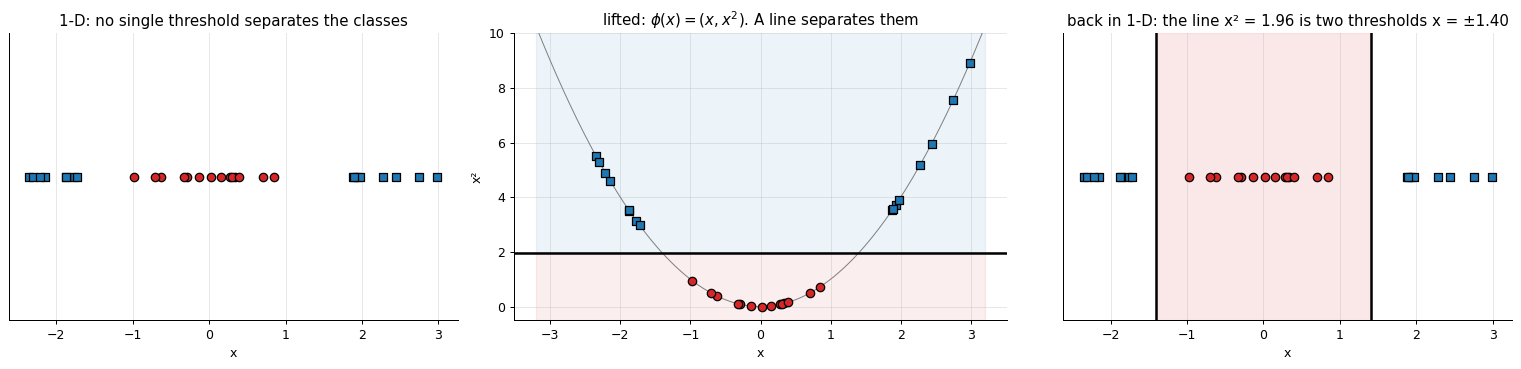

In [12]:
x1d = np.r_[rng.uniform(-1, 1, 14), rng.uniform(1.6, 3, 8), rng.uniform(-3, -1.6, 8)]
y1d = np.r_[np.ones(14), -np.ones(16)]
cut = (np.abs(x1d[y1d > 0]).max() ** 2 + np.abs(x1d[y1d < 0]).min() ** 2) / 2      # midway in x²

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), gridspec_kw={"width_ratios": [1, 1.1, 1]})
def dots(ax, xx, yy):
    ax.scatter(xx[y1d > 0], yy[y1d > 0], c=POS, marker="o", edgecolor="k", s=45, zorder=3)
    ax.scatter(xx[y1d < 0], yy[y1d < 0], c=NEG, marker="s", edgecolor="k", s=45, zorder=3)
dots(axes[0], x1d, 0 * x1d); axes[0].set_yticks([]); axes[0].set_xlabel("x")
axes[0].set_title("1-D: no single threshold separates the classes")

ax = axes[1]; xx = np.linspace(-3.2, 3.2, 200)
ax.plot(xx, xx ** 2, c="gray", lw=0.8); dots(ax, x1d, x1d ** 2)
ax.axhline(cut, c="k", lw=2); ax.fill_between(xx, cut, 11, color=NEG, alpha=0.08); ax.fill_between(xx, -0.5, cut, color=POS, alpha=0.08)
ax.set_ylim(-0.5, 10); ax.set_xlabel("x"); ax.set_ylabel("x²")
ax.set_title(r"lifted: $\phi(x) = (x, x^2)$. A line separates them")

ax = axes[2]; r = np.sqrt(cut)
ax.axvspan(-r, r, color=POS, alpha=0.1); ax.axvline(-r, c="k", lw=2); ax.axvline(r, c="k", lw=2)
dots(ax, x1d, 0 * x1d); ax.set_yticks([]); ax.set_xlabel("x")
ax.set_title(f"back in 1-D: the line x² = {cut:.2f} is two thresholds x = ±{r:.2f}")
plt.tight_layout(); plt.show()

The same trick in 2-D: concentric circles become separable by a **plane** once we add the feature $z = x_1^2 + x_2^2$ (squared distance to the origin). The plane $\theta_1x_1 + \theta_2x_2 + \theta_3(x_1^2+x_2^2) + \theta_0 = 0$ is a circle in the original plane.

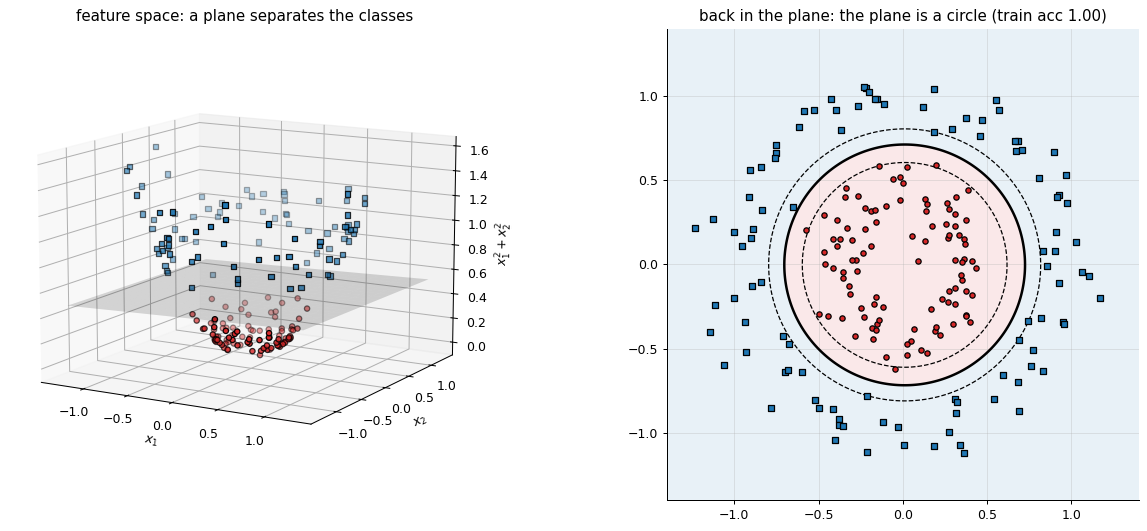

In [13]:
from sklearn.datasets import make_circles
Xc, yc = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=0)
yc = np.where(yc == 1, 1.0, -1.0)                                  # inner circle = +1
Phi = np.c_[Xc, (Xc ** 2).sum(1)]                                  # φ(x) = (x1, x2, x1² + x2²)
lift = SVC(kernel="linear", C=10).fit(Phi, yc)
w, w0 = lift.coef_[0], lift.intercept_[0]

fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*Phi[yc > 0].T, c=POS, marker="o", edgecolor="k", s=18)
ax.scatter(*Phi[yc < 0].T, c=NEG, marker="s", edgecolor="k", s=18)
P1, P2 = np.meshgrid(np.linspace(-1.3, 1.3, 20), np.linspace(-1.3, 1.3, 20))
ax.plot_surface(P1, P2, -(w[0] * P1 + w[1] * P2 + w0) / w[2], color="k", alpha=0.15)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$x_1^2+x_2^2$"); ax.view_init(elev=12, azim=-60)
ax.set_title("feature space: a plane separates the classes")

ax = fig.add_subplot(1, 2, 2)
lim = (-1.4, 1.4); g1, g2 = np.meshgrid(np.linspace(*lim, 300), np.linspace(*lim, 300))
F = w[0] * g1 + w[1] * g2 + w[2] * (g1 ** 2 + g2 ** 2) + w0
ax.contourf(g1, g2, F, levels=[-1e9, 0, 1e9], colors=[NEG, POS], alpha=0.1)
ax.contour(g1, g2, F, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=[1, 2, 1])
scatter_classes(ax, Xc, yc, s=18); ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_title(f"back in the plane: the plane is a circle (train acc {lift.score(Phi, yc):.2f})")
plt.tight_layout(); plt.show()

**The trick: never compute $\phi$.** Look at section 7 again. In the dual objective and in the prediction $f(\mathbf{x}) = \sum_i\alpha_iy^{(i)}\,\mathbf{x}^{(i)\top}\mathbf{x} + \theta_0$, the data appear **only through dot products**. After the mapping these become $\phi(\mathbf{x}^{(i)})^\top\phi(\mathbf{x}^{(j)})$. If a function $K$ computes that dot product directly,

$$
K(\mathbf{x}, \mathbf{z}) = \phi(\mathbf{x})^\top\phi(\mathbf{z}),
$$

we just replace every $\mathbf{x}^{(i)\top}\mathbf{x}^{(j)}$ by $K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)})$:

$$
\max_{\boldsymbol{\alpha}}\ \sum_i\alpha_i - \frac12\sum_{i,j}\alpha_i\alpha_jy^{(i)}y^{(j)}K(\mathbf{x}^{(i)},\mathbf{x}^{(j)})
\quad\text{s.t. } 0\le\alpha_i\le C,\ \sum_i\alpha_iy^{(i)}=0,
\qquad
f(\mathbf{x}) = \sum_{i\in\text{SV}}\alpha_iy^{(i)}K(\mathbf{x}^{(i)},\mathbf{x}) + \theta_0 .
$$

This is a linear SVM in $\phi$-space, and we never build $\phi$.

**Example: the polynomial kernel.** In 2-D,
$$
(\mathbf{x}^\top\mathbf{z} + 1)^2 = (x_1z_1 + x_2z_2 + 1)^2 = x_1^2z_1^2 + x_2^2z_2^2 + 2x_1x_2z_1z_2 + 2x_1z_1 + 2x_2z_2 + 1 = \phi(\mathbf{x})^\top\phi(\mathbf{z})
$$
with $\phi(\mathbf{x}) = (1,\ \sqrt2x_1,\ \sqrt2x_2,\ x_1^2,\ x_2^2,\ \sqrt2x_1x_2)$: all monomials of degree ≤ 2. The kernel costs one 2-D dot product. $\phi$ has 6 coordinates, and for degree $d$ in $n$ dimensions it has $\binom{n+d}{d}$ (for $n = 100, d = 3$: 176 851).

**The RBF (Gaussian) kernel** $K(\mathbf{x}, \mathbf{z}) = \exp(-\gamma\lVert\mathbf{x} - \mathbf{z}\rVert^2)$ corresponds to an *infinite*-dimensional $\phi$. It is easier to read from the prediction formula: $f(\mathbf{x})$ is a **sum of Gaussian bumps**, one centred on each support vector, pointing up for $+1$ and down for $-1$, with height $\alpha_i$. $\gamma$ sets their width.

(a·b + 1)² = 2.606880    φ(a)·φ(b) = 2.606880
max |f_ours − f_sklearn| on the grid: 4.93e-04


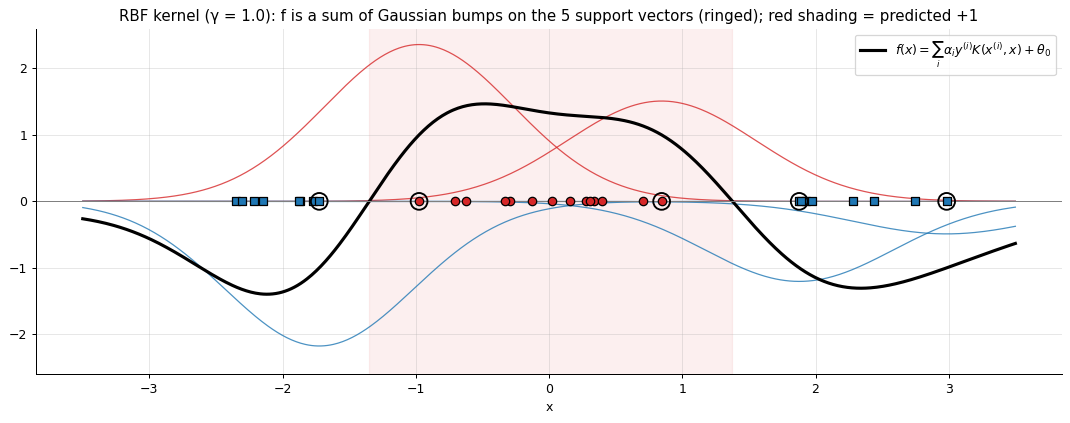

In [14]:
def phi2(v):                                       # explicit feature map of (x·z + 1)² in 2-D
    x1, x2 = v
    return np.array([1, np.sqrt(2) * x1, np.sqrt(2) * x2, x1 ** 2, x2 ** 2, np.sqrt(2) * x1 * x2])
a, b = rng.normal(size=2), rng.normal(size=2)
print(f"(a·b + 1)² = {(a @ b + 1) ** 2:.6f}    φ(a)·φ(b) = {phi2(a) @ phi2(b):.6f}")

# RBF kernel SVM on the 1-D data, solved with OUR dual solver (only the kernel changed)
gamma = 1.0
rbf = lambda A, B: np.exp(-gamma * ((A[:, None, :] - B[None, :, :]) ** 2).sum(-1))
X1 = x1d[:, None]
alpha1, theta0_1 = svm_dual(X1, y1d, C=10, kernel=rbf)
xx = np.linspace(-3.5, 3.5, 600)[:, None]
bumps = (alpha1 * y1d)[:, None] * rbf(X1, xx)                    # one row per training point
f1 = bumps.sum(0) + theta0_1
sk1 = SVC(kernel="rbf", gamma=gamma, C=10).fit(X1, y1d)
print(f"max |f_ours − f_sklearn| on the grid: {np.abs(f1 - sk1.decision_function(xx)).max():.2e}")

fig, ax = plt.subplots(figsize=(12, 4.8))
for i in np.flatnonzero(alpha1):
    ax.plot(xx, bumps[i], c=POS if y1d[i] > 0 else NEG, lw=1, alpha=0.8)
ax.plot(xx, f1, "k", lw=2.5, label=r"$f(x)=\sum_i\alpha_iy^{(i)}K(x^{(i)},x)+\theta_0$")
ax.axhline(0, c="gray", lw=0.8); ax.fill_between(xx[:, 0], -3, 3, where=f1 > 0, color=POS, alpha=0.07)
ax.scatter(x1d[y1d > 0], 0 * x1d[y1d > 0], c=POS, edgecolor="k", s=45, zorder=4)
ax.scatter(x1d[y1d < 0], 0 * x1d[y1d < 0], c=NEG, marker="s", edgecolor="k", s=45, zorder=4)
ax.scatter(x1d[alpha1 > 0], 0 * x1d[alpha1 > 0], s=180, facecolors="none", edgecolors="k", lw=1.5, zorder=5)
ax.set_ylim(-2.6, 2.6); ax.set_xlabel("x"); ax.legend(loc="upper right")
ax.set_title(f"RBF kernel (γ = {gamma}): f is a sum of Gaussian bumps on the {int((alpha1 > 0).sum())} support vectors "
             "(ringed); red shading = predicted +1")
plt.tight_layout(); plt.show()

The width of the bumps is the key hyperparameter. On the circles data: a linear kernel fails; small $\gamma$ gives wide bumps and a smooth boundary (can underfit); large $\gamma$ gives narrow bumps around each point, which memorise the training set (overfit, almost every point becomes a support vector).

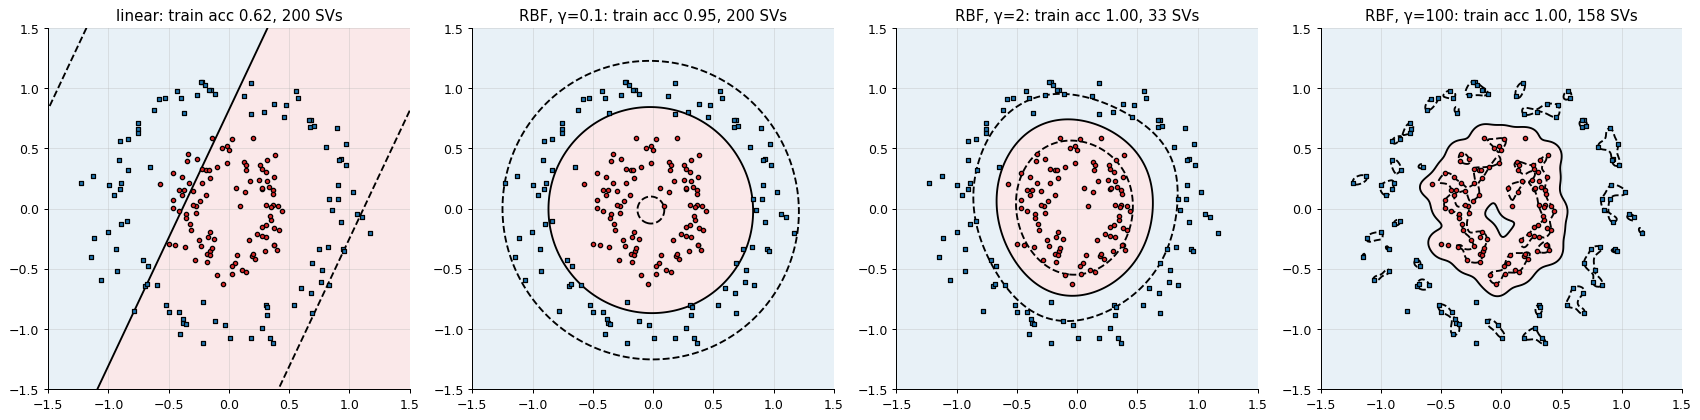

In [15]:
g1, g2 = np.meshgrid(np.linspace(-1.5, 1.5, 300), np.linspace(-1.5, 1.5, 300)); G = np.c_[g1.ravel(), g2.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
for ax, (kern, kw, name) in zip(axes, [("linear", {}, "linear"), ("rbf", {"gamma": 0.1}, "RBF, γ=0.1"),
                                       ("rbf", {"gamma": 2}, "RBF, γ=2"), ("rbf", {"gamma": 100}, "RBF, γ=100")]):
    s = SVC(kernel=kern, C=1, **kw).fit(Xc, yc); F = s.decision_function(G).reshape(g1.shape)
    ax.contourf(g1, g2, F, levels=[-1e9, 0, 1e9], colors=[NEG, POS], alpha=0.1)
    ax.contour(g1, g2, F, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
    scatter_classes(ax, Xc, yc, s=12); ax.set_aspect("equal")
    ax.set_title(f"{name}: train acc {s.score(Xc, yc):.2f}, {len(s.support_)} SVs")
plt.tight_layout(); plt.show()

Tune $C$ and $\gamma$ together by cross-validation on a log grid.

## 10. The hinge loss

So far the SVM came from geometry. Now we show that it is also an ordinary **"loss + regulariser"** model, just like regularised linear and logistic regression.

**Eliminate the slacks.** In the soft-margin problem, for fixed $(\boldsymbol{\theta},\theta_0)$ each $\xi^{(i)}$ appears only in its own two constraints $\xi^{(i)}\ge 1-\mu^{(i)}$ and $\xi^{(i)}\ge0$, and the objective wants it as small as possible. So at the optimum

$$
\xi^{(i)} = \max\big(0,\; 1 - \mu^{(i)}\big) = \max\big(0,\; 1 - y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0)\big).
$$

This is the **hinge loss** $\ell_{\text{hinge}}(\mu) = \max(0, 1-\mu)$. Substituting it gives an **unconstrained** problem:

$$
\min_{\boldsymbol{\theta},\theta_0}\;\frac12\lVert\boldsymbol{\theta}\rVert^2 + C\sum_{i=1}^m\max\big(0,\,1 - y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0)\big).
$$

Divide by $Cm$ (this doesn't change the minimiser) and set $\lambda = \frac{1}{Cm}$:

$$
\boxed{J(\boldsymbol{\theta},\theta_0) = \frac{1}{m}\sum_{i=1}^m\max\big(0,\,1 - y^{(i)}(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}+\theta_0)\big) + \frac{\lambda}{2}\lVert\boldsymbol{\theta}\rVert^2}
$$

This is **average loss + L2 regularisation**, the same template as notebook 03. Only the loss changed. The geometric SVM and the hinge-loss SVM are the same problem. $\blacksquare$

**Reading the two terms with Part I.** The regulariser $\frac{\lambda}{2}\lVert\boldsymbol{\theta}\rVert^2$ keeps $\boldsymbol{\theta}$ short, which by step 4 means a **wide margin** $2/\lVert\boldsymbol{\theta}\rVert$. The hinge term charges each point that is on the wrong side of its dashed line. Here the L2 regulariser is not an add-on: it *is* the margin.

**The hinge loss has three regions** (in terms of $\mu = yf(\mathbf{x})$):
- $\mu\ge1$: loss 0, flat. The point is safely outside the margin and **has no influence at all**.
- $0\le\mu<1$: correct but inside the margin; small linear penalty.
- $\mu<0$: misclassified; the penalty grows linearly.

**Convexity.** $\max(0, 1-\mu)$ is a maximum of two affine functions of $(\boldsymbol{\theta},\theta_0)$, hence convex; plus a convex quadratic. So $J$ is convex: every local minimum is global. But it is **not differentiable** at $\mu = 1$, so we need sub-gradients (section 11).

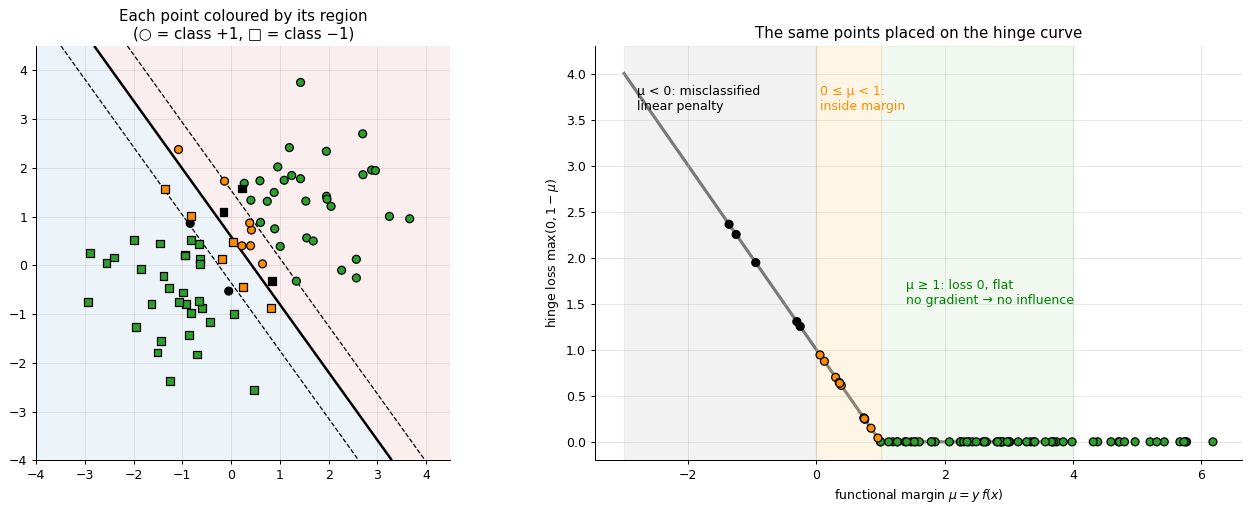

In [16]:
REGION = lambda mu: np.where(mu >= 1, "C2", np.where(mu >= 0, "darkorange", "k"))
th, th0 = soft.coef_[0], soft.intercept_[0]              # the C = 1 soft-margin SVM of section 8
mu_o = yo * (Xo @ th + th0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
ax = axes[0]
draw_boundary(ax, th, th0, lim_o)
for sgn, mk in [(1, "o"), (-1, "s")]:
    sel = yo == sgn
    ax.scatter(Xo[sel, 0], Xo[sel, 1], c=REGION(mu_o[sel]), marker=mk, edgecolor="k", s=40, zorder=3)
ax.set_title("Each point coloured by its region\n(○ = class +1, □ = class −1)")

ax = axes[1]
mu = np.linspace(-3, 4, 500)
ax.plot(mu, np.maximum(0, 1 - mu), c="gray", lw=2.5, zorder=1)
ax.axvspan(-3, 0, color="k", alpha=0.05); ax.axvspan(0, 1, color="orange", alpha=0.1); ax.axvspan(1, 4, color="C2", alpha=0.07)
ax.scatter(mu_o, np.maximum(0, 1 - mu_o), c=REGION(mu_o), edgecolor="k", s=40, zorder=3)
ax.text(-2.8, 3.6, "μ < 0: misclassified\nlinear penalty", fontsize=10)
ax.text(0.05, 3.6, "0 ≤ μ < 1:\ninside margin", fontsize=10, color="darkorange")
ax.text(1.4, 1.5, "μ ≥ 1: loss 0, flat\nno gradient → no influence", fontsize=10, color="green")
ax.set_xlabel(r"functional margin $\mu = y\,f(x)$"); ax.set_ylabel(r"hinge loss $\max(0, 1-\mu)$"); ax.set_ylim(-0.2, 4.3)
ax.set_title("The same points placed on the hinge curve")
plt.tight_layout(); plt.show()

### Hinge vs. logistic loss

Logistic regression can be written with $\pm1$ labels too. With $y\in\{-1,+1\}$ and $P(y=+1\mid\mathbf{x}) = \sigma(f)$, symmetry of the sigmoid gives $P(y\mid\mathbf{x}) = \sigma(yf)$ for both labels. The loss is

$$
-\log\sigma(yf) = \log\big(1 + e^{-yf}\big) = \log\big(1 + e^{-\mu}\big),
$$

which is just binary cross-entropy rewritten. Now both methods are "regularised loss of the margin $\mu$", and they differ only in the shape of the loss:

- Both are convex upper bounds (up to scaling) of the **0–1 loss** $\mathbb{1}[\mu\le 0]$, which is what we really want to minimise but which has zero gradient almost everywhere.
- The logistic loss is **never exactly 0**: every point, however well classified, still pulls on $\boldsymbol{\theta}$. The hinge loss is exactly 0 for $\mu\ge1$, so only points on or inside the margin matter. That is where the **sparsity** of SVMs comes from.
- Logistic regression gives probabilities; the SVM gives only a score $f(\mathbf{x})$.

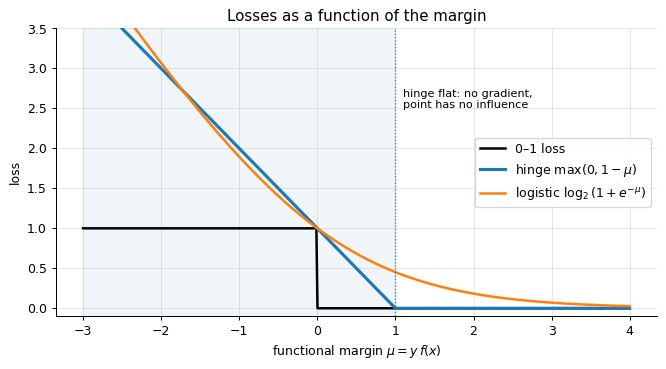

In [17]:
mu = np.linspace(-3, 4, 500)
plt.figure(figsize=(7.5, 4.2))
plt.plot(mu, (mu <= 0).astype(float), "k", lw=2, label="0–1 loss")
plt.plot(mu, np.maximum(0, 1 - mu), lw=2.5, label=r"hinge $\max(0,1-\mu)$")
plt.plot(mu, np.log2(1 + np.exp(-mu)), lw=2, label=r"logistic $\log_2(1+e^{-\mu})$")
plt.axvspan(-3, 1, color="C0", alpha=0.07); plt.axvline(1, color="C0", ls=":", lw=1)
plt.text(1.1, 2.5, "hinge flat: no gradient,\npoint has no influence", fontsize=9)
plt.xlabel(r"functional margin $\mu = y\,f(x)$"); plt.ylabel("loss"); plt.ylim(-0.1, 3.5); plt.legend()
plt.title("Losses as a function of the margin"); plt.tight_layout(); plt.show()

## 11. Training with sub-gradient descent, and support vectors

**Sub-gradient.** For a convex function with a kink, a sub-gradient at a point is the slope of any line that touches the function there and stays below it. Away from kinks it is the ordinary gradient. For one hinge term with respect to $\boldsymbol{\theta}$:

$$
\partial_{\boldsymbol{\theta}}\max\big(0, 1-\mu^{(i)}\big) \ni
\begin{cases}
-y^{(i)}\mathbf{x}^{(i)} & \mu^{(i)} < 1\\
\mathbf{0} & \mu^{(i)} > 1\\
\text{anything in between; we take } \mathbf{0} & \mu^{(i)} = 1
\end{cases}
\qquad(\text{same with } \mathbf{x}^{(i)} \text{ replaced by } 1 \text{ for } \theta_0).
$$

Let $V = \{i : \mu^{(i)} < 1\}$ be the set of **margin violators**. A sub-gradient of $J$ is

$$
\mathbf{g}_{\boldsymbol{\theta}} = \lambda\boldsymbol{\theta} - \frac{1}{m}\sum_{i\in V}y^{(i)}\mathbf{x}^{(i)}, \qquad
g_{\theta_0} = -\frac{1}{m}\sum_{i\in V}y^{(i)}.
$$

**Update rule.**
$$
\boldsymbol{\theta} \leftarrow \underbrace{(1 - \eta_t\lambda)\,\boldsymbol{\theta}}_{\text{weight decay: widens the margin}} + \underbrace{\frac{\eta_t}{m}\sum_{i\in V}y^{(i)}\mathbf{x}^{(i)}}_{\text{each violator pulls the boundary away from itself}}, \qquad
\theta_0 \leftarrow \theta_0 + \frac{\eta_t}{m}\sum_{i\in V}y^{(i)} .
$$

At the optimum the two forces balance. Points outside the margin exert no force at all.

**Step size must decay.** With a constant step the sub-gradient jumps every time a point crosses $\mu=1$ and the boundary jitters forever. Use e.g. $\eta_t = \eta_0/\sqrt{1+t}$ or $1/(\lambda t)$ (the *Pegasos* algorithm, which uses one random example or a mini-batch per step and scales to millions of examples).

In [18]:
def svm_objective(theta, theta0, X, y, lam):
    mu = y * (X @ theta + theta0)
    return np.mean(np.maximum(0, 1 - mu)) + lam / 2 * theta @ theta

def svm_subgradient_descent(X, y, lam, eta0=1.0, T=5000, theta=None, theta0=0.0, snapshots=()):
    m, n = X.shape
    theta = np.zeros(n) if theta is None else np.asarray(theta, float)
    history, snaps = [], {}
    for t in range(T):
        if t in snapshots:
            snaps[t] = (theta.copy(), theta0)
        mu = y * (X @ theta + theta0)
        V = mu < 1                                            # margin violators
        g = lam * theta - (y[V, None] * X[V]).sum(0) / m
        g0 = -y[V].sum() / m
        eta = eta0 / np.sqrt(1 + t)
        theta, theta0 = theta - eta * g, theta0 - eta * g0
        history.append(svm_objective(theta, theta0, X, y, lam))
    snaps[T] = (theta.copy(), theta0)
    return theta, theta0, np.array(history), snaps

lam = 0.01
theta, theta0, hist, _ = svm_subgradient_descent(X, y, lam)
print(f"from scratch: theta = {theta.round(3)}, theta0 = {theta0:.3f}, J = {hist[-1]:.4f}")

sk = SVC(kernel="linear", C=1 / (lam * len(y))).fit(X, y)       # lambda = 1 / (C m)
print(f"sklearn SVC : theta = {sk.coef_[0].round(3)}, theta0 = {sk.intercept_[0]:.3f}, "
      f"J = {svm_objective(sk.coef_[0], sk.intercept_[0], X, y, lam):.4f}")

from scratch: theta = [1.03  0.761], theta0 = -1.001, J = 0.0082
sklearn SVC : theta = [1.03  0.761], theta0 = -1.001, J = 0.0082


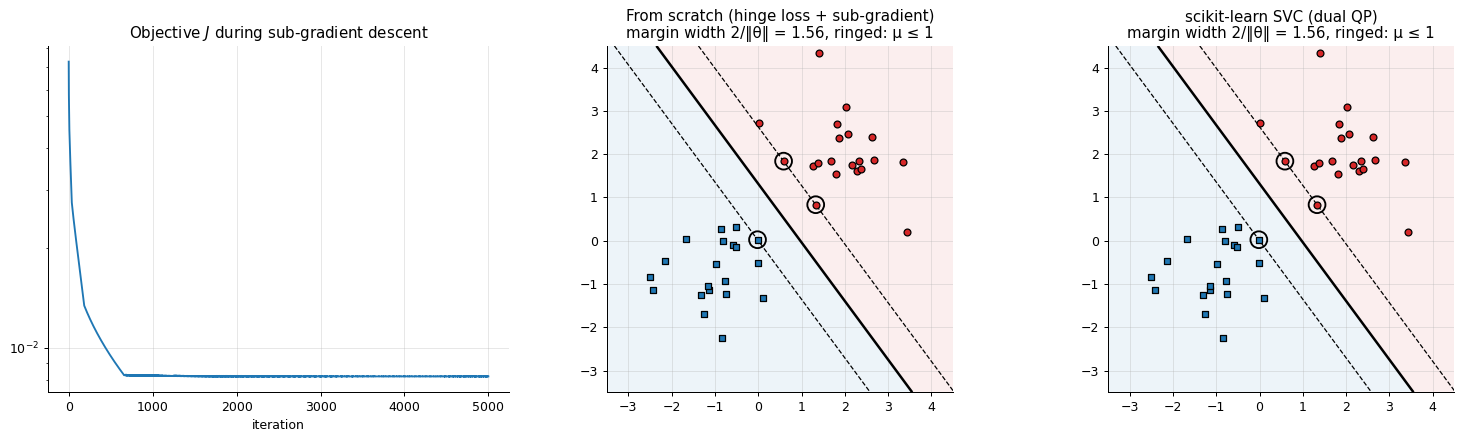

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(hist); axes[0].set_yscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_title("Objective $J$ during sub-gradient descent")
plot_svm(axes[1], theta, theta0, X, y, "From scratch (hinge loss + sub-gradient)")
plot_svm(axes[2], sk.coef_[0], sk.intercept_[0], X, y, "scikit-learn SVC (dual QP)")
plt.tight_layout(); plt.show()

**Watching it train.** Start from a deliberately bad boundary. The top row shows the boundary, the bottom row every point placed on the hinge curve at its current margin. Early on, many points sit on the sloped part of the hinge and pull on $\boldsymbol{\theta}$. Training moves them to the right. Once a point passes $\mu = 1$ it falls onto the flat part and stops contributing. At the end only the points at the kink, the support vectors, are left.

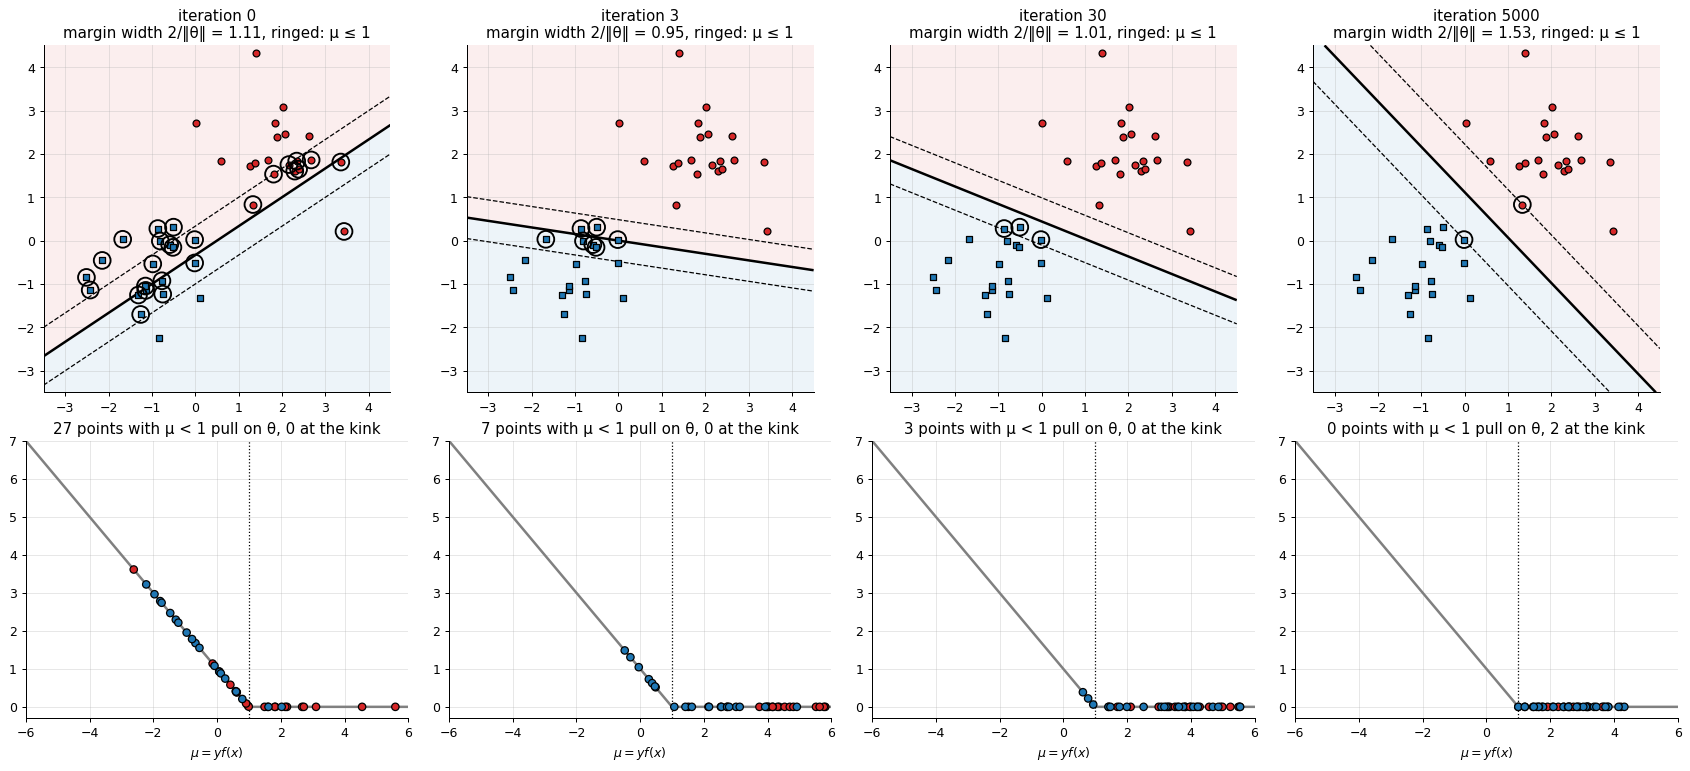

In [20]:
steps = (0, 3, 30)
_, _, _, snaps = svm_subgradient_descent(X, y, lam, theta=[-1.0, 1.5], theta0=0.5, snapshots=steps)
fig, axes = plt.subplots(2, 4, figsize=(19, 8.6), gridspec_kw={"height_ratios": [1.25, 1]})
mu_grid = np.linspace(-6, 6, 400)
for col, (t, (th, th0)) in enumerate(sorted(snaps.items())):
    plot_svm(axes[0, col], th, th0, X, y, f"iteration {t}")
    mu_t = y * (X @ th + th0); viol = mu_t < 1 - 1e-3; kink = np.abs(mu_t - 1) <= 1e-3
    ax = axes[1, col]
    ax.plot(mu_grid, np.maximum(0, 1 - mu_grid), c="gray", lw=2)
    ax.scatter(mu_t, np.maximum(0, 1 - mu_t), c=np.where(y > 0, POS, NEG), edgecolor="k", s=35, zorder=3)
    ax.axvline(1, c="k", ls=":", lw=1); ax.set_xlim(-6, 6); ax.set_ylim(-0.3, 7)
    ax.set_xlabel(r"$\mu = y f(x)$"); ax.set_title(f"{viol.sum()} points with μ < 1 pull on θ, {kink.sum()} at the kink")
plt.tight_layout(); plt.show()

### The effect of $\lambda$ is the effect of $C$

Since $\lambda = 1/(Cm)$, a small $\lambda$ (large $C$) makes violations expensive and gives a narrow margin, and a large $\lambda$ (small $C$) gives a wide margin with many violations. It is the same trade-off as in section 8, seen from the loss side.

### Support vectors, from the loss side

Look at the update rule. It starts at $\boldsymbol{\theta} = \mathbf{0}$ and only ever (a) rescales $\boldsymbol{\theta}$ and (b) adds multiples of $y^{(i)}\mathbf{x}^{(i)}$ for violators. So at every step, and at the optimum,

$$
\boldsymbol{\theta} = \sum_{i=1}^m\beta_i\,y^{(i)}\mathbf{x}^{(i)}, \qquad \beta_i \ne 0 \text{ only for points with } \mu^{(i)}\le 1 .
$$

This is the same statement as $\boldsymbol{\theta} = \sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)}$ from the dual (section 7), reached from the loss side. Those points (on the margin, inside it, or misclassified) are the **support vectors**. The solution depends on them and nothing else:

- deleting or moving any other point (on its own side, outside the margin) does not change the classifier;
- this comes directly from the flat part of the hinge loss. Logistic regression has no flat part, so it uses every point;
- and because $\boldsymbol{\theta}$ is a weighted sum of training points, $f(\mathbf{x})$ only needs dot products with them. That is why kernels work.

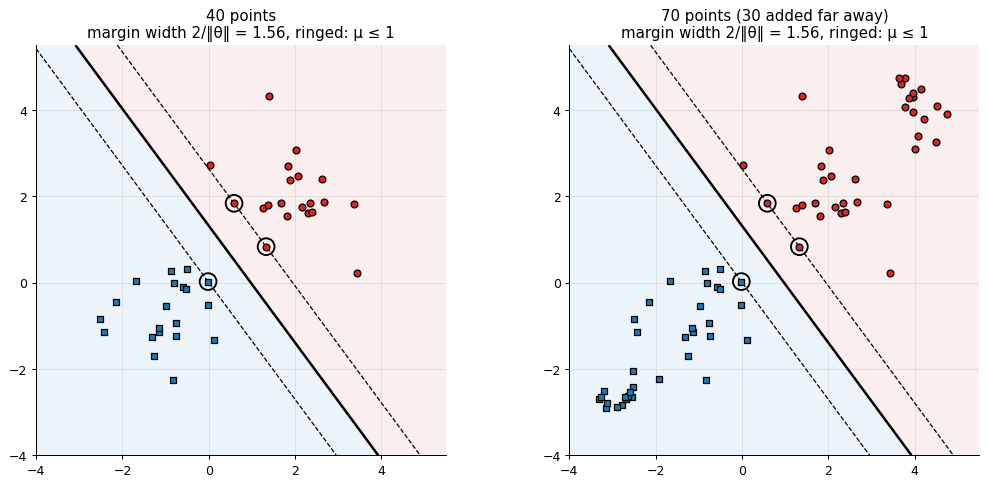

theta before: [1.0301 0.7606]  after: [1.0302 0.7606]


In [21]:
# Adding points far from the margin does not change the SVM
Xfar = np.r_[X, rng.normal([4, 4], 0.4, (15, 2)), rng.normal([-2.8, -2.5], 0.3, (15, 2))]
yfar = np.r_[y, np.ones(15), -np.ones(15)]
s1 = SVC(kernel="linear", C=1e3).fit(X, y); s2 = SVC(kernel="linear", C=1e3).fit(Xfar, yfar)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plot_svm(axes[0], s1.coef_[0], s1.intercept_[0], X, y, f"{len(y)} points", lim=(-4, 5.5))
plot_svm(axes[1], s2.coef_[0], s2.intercept_[0], Xfar, yfar, f"{len(yfar)} points (30 added far away)", lim=(-4, 5.5))
plt.tight_layout(); plt.show()
print("theta before:", s1.coef_[0].round(4), " after:", s2.coef_[0].round(4))

## 12. Practical notes and summary

- **Scale the features.** The margin is a Euclidean distance, so a feature in large units dominates it.
- **No probabilities** out of the box: $f(\mathbf{x})$ is a score. `SVC(probability=True)` fits a sigmoid on top (Platt scaling) using internal CV.
- **Multiclass**: one-vs-one (`SVC`) or one-vs-rest (`LinearSVC`).
- **Cost**: kernel SVMs need the $m\times m$ kernel matrix; roughly $O(m^2)$–$O(m^3)$ training, so beyond ~$10^5$ examples use linear SVMs (sub-gradient/Pegasos, `LinearSVC`, `SGDClassifier(loss="hinge")`).
- `SVC(C=...)` corresponds to our $\lambda = 1/(Cm)$.

| | Logistic regression | Linear SVM |
|---|---|---|
| Loss of the margin $\mu$ | $\log(1+e^{-\mu})$ | $\max(0, 1-\mu)$ |
| Regulariser | L2 (usually) | L2 (always: it *is* the margin) |
| Which points matter | all | support vectors only |
| Output | calibrated probability | score / class |
| Solver | GD, Newton, L-BFGS | sub-gradient (primal) or QP/SMO (dual) |

## Summary

| step | idea | formula |
|---|---|---|
| 1 · hyperplane | boundary is $f = 0$, side is the sign | $\hat{y} = \mathrm{sign}(\boldsymbol{\theta}^\top\mathbf{x} + \theta_0)$ |
| 2 · projection | dot product = shadow on $\boldsymbol{\theta}$ ⇒ distance | $r = f(\mathbf{x})/\lVert\boldsymbol{\theta}\rVert$ |
| 3 · scale | closest points at $f = \pm1$ | $y^{(i)}f(\mathbf{x}^{(i)}) \ge 1$, equality for SVs |
| 4 · margin | project $\mathbf{x}_+, \mathbf{x}_-$ and subtract | $d = 2/\lVert\boldsymbol{\theta}\rVert$ |
| 5 · optimise | widest margin = shortest $\boldsymbol{\theta}$ | $\min \frac12\lVert\boldsymbol{\theta}\rVert^2$ s.t. $y^{(i)}f(\mathbf{x}^{(i)})\ge1$ |
| dual | Lagrange; only active constraints count | $\boldsymbol{\theta} = \sum_i\alpha_iy^{(i)}\mathbf{x}^{(i)}$, $\alpha_i > 0$ only for SVs |
| soft margin | slacks with price $C$ | $0 \le \alpha_i \le C$ |
| kernels | data enter only via dot products | $\mathbf{x}^\top\mathbf{z} \to K(\mathbf{x}, \mathbf{z})$ |
| hinge loss | eliminate the slacks | $J = \frac1m\sum_i\max(0, 1-\mu^{(i)}) + \frac\lambda2\lVert\boldsymbol{\theta}\rVert^2$, $\lambda = \frac{1}{Cm}$ |

- $J$ is convex but not differentiable → sub-gradient descent with decaying step (primal), or a QP solver (dual).
- Only support vectors ($\mu\le1$) determine the solution: the flat part of the hinge, the zero multipliers of the dual, and the inactive constraints of step 5 are three views of the same fact.